**Lab2-DL: B4-ECG-arrhythmia-CNN.ipynb** (BMED365) | Priority: 1 (core)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/B4-ECG-arrhytmia-CNN.ipynb)

# 🫀 B4: ECG Arrhythmia Classification with Neural Networks

**Practical Implementation of CNN for Medical Signal Analysis**

---

## 🎯 Learning Objectives

In this notebook we will:
- **Understand** ECG signals and the MIT-BIH Arrhythmia Database
- **Implement** CNN for 1D signal classification
- **Train** a model on real medical data
- **Evaluate** and interpret results in a clinical context
- **Reflect** on ethical and practical aspects

## 📋 Contents

1. **ECG signals and arrhythmias** - Medical background
2. **MIT-BIH Database** - Dataset and annotations
3. **Data handling** - Download and preprocessing
4. **CNN architecture** - Design for ECG classification
5. **Training and optimization** - Practical implementation
6. **Evaluation** - Metrics and clinical interpretation
7. **Reflections** - Ethics and future work

---

## 🏥 Clinical Relevance

**For Physicians:**
- Emergency medicine: Rapid detection of life-threatening arrhythmias
- Cardiology: Early detection of cardiovascular diseases
- Anesthesia: Monitoring cardiac function during operations

**For Psychologists:**
- Heart rate variability (HRV) and stress response
- Psychosomatic medicine and mental health

**For Nurses:**
- Continuous ECG monitoring in hospitals
- Triage and patient assessment


In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
from matplotlib.patches import Circle, FancyBboxPatch
import warnings
import time
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from scipy.signal import butter, filtfilt
import platform
import subprocess
import sys

warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🫀 Ready for ECG arrhythmia classification!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")


🫀 Ready for ECG arrhythmia classification!
PyTorch version: 2.6.0
CUDA available: False
MPS available: True


## 1. ECG Signals and Arrhythmias

### 🫀 Why ECG as an Example of Neural Networks in Medicine?

**Direct Connection to Action Potentials:**
ECG (electrocardiography) is the perfect bridge between biological action potentials and artificial neurons. The heart's electrical activity is directly related to the action potentials we studied earlier:

- **Cardiac muscle cells** use the same ion channels as nerve cells
- **Sodium, potassium, and calcium ions** create the heart's electrical signals
- **Depolarization and repolarization** occur in the same way as in nerve cells
- **ECG measurements** record these electrical signals from the body's surface

**From Biology to AI:**
- **Biological**: Action potentials in cardiac muscle cells
- **Measurement**: ECG recording of electrical signals
- **AI**: Neural networks that analyze ECG patterns
- **Clinical**: Automatic detection of arrhythmias and myocardial infarction

### 🏥 Clinical Relevance for Healthcare Professionals

**For Physicians:**
- **Emergency medicine**: Rapid detection of life-threatening arrhythmias
- **Cardiology**: Early detection of cardiovascular diseases
- **Anesthesia**: Monitoring cardiac function during operations
- **Intensive care medicine**: Continuous monitoring of critical patients

**For Psychologists:**
- **Heart rate variability (HRV)**: The variation in time intervals between heartbeats
  - *Definition*: HRV is a measure of autonomic nervous system function and stress response
  - *Clinical significance*: Low HRV is associated with stress, anxiety, depression, and increased risk of cardiovascular disease
  - *Treatment*: HRV biofeedback is used in the treatment of anxiety and stress disorders
- **Psychosomatic medicine**: Connection between mental health and cardiac function
- **Stress research**: Objective measurement of stress response

**For Nurses:**
- **Monitoring**: Continuous ECG monitoring in hospitals
- **Triage**: Rapid assessment of patients with chest pain
- **Rehabilitation**: Monitoring during cardiac rehabilitation
- **Home care**: Remote monitoring of chronic patients


## 2. MIT-BIH Arrhythmia Database

### 📊 MIT-BIH Arrhythmia Database: A Golden Standard

**What is the MIT-BIH Arrhythmia Database?**
- **Created**: 1980-1990 by Massachusetts Institute of Technology and Beth Israel Hospital
- **Contents**: 48 two-channel ECG recordings, each 30 minutes long
- **Sampling rate**: 360 Hz (360 measurements per second)
- **Annotations**: Experts have marked each heartbeat with a diagnosis
- **Open access**: Freely available for research and education

**Why is this database so important?**
- **Golden standard**: Used as reference for all ECG algorithms
- **Clinically validated**: Annotations from experts
- **Reproducibility**: Standardized format and quality
- **Research**: Foundation for thousands of scientific articles

### 🔢 Record Numbering and Structure

**The record numbers** in MIT-BIH Arrhythmia Database represent:

##### **100-124**: **First group (25 records)**
- **Randomly selected** from 4000 24-hour ECG recordings
- **Mixed population**: 60% inpatients, 40% outpatients
- **Represents** typical ECG patterns in the general population

##### **200-234**: **Second group (25 records)**
- **Selectively chosen** to include rare but clinically important arrhythmias
- **Contains** specific arrhythmia types that would not be well represented in random selection
- **Examples**: Ventricular tachycardia, atrial fibrillation, complex arrhythmias

### 📁 File Types and Format

##### **`.hea` file (Header file)**
- **Contents**: Metadata for ECG record
- **Example contents**:
  ```
  Record: 100
  Number of signals: 2
  Sampling frequency: 360 Hz
  Number of samples: 650000
  Signal 1: MLII (modified lead II)
  Signal 2: V5
  ```
- **Used for**: Describes how the ECG signal should be read

##### **`.dat` file (Data file)**
- **Contents**: The actual ECG signal data
- **Format**: Binary format with 11-bit resolution
- **Contents**: 
  - Two channels (MLII and V5)
  - 360 samples per second
  - 30 minutes of data (650,000 samples)
  - Amplitude values in millivolts (mV)
- **Used for**: The actual ECG measurement

##### **`.atr` file (Annotation file)**
- **Contents**: Annotations and markings of heartbeats
- **Format**: Binary format with annotation data
- **Contents**:
  - **R-peak positions**: When each heartbeat occurs
  - **Arrhythmia classification**: What type of heartbeat (N, L, R, A, V)
  - **Timestamp**: Exact time of each annotation
- **Used for**: Automatic detection and classification of arrhythmias

### 🏷️ Arrhythmia Classification

**5 main classes we will classify:**

| Symbol | Name | Description |
|--------|------|-------------|
| **N** | Normal Beat | Normal sinus rhythm |
| **L** | Left Bundle Branch Block | Block in the left bundle branch |
| **R** | Right Bundle Branch Block | Block in the right bundle branch |
| **A** | Atrial Premature Beat | Early beats from the atrium |
| **V** | Premature Ventricular Contraction | Early beats from the ventricle |


## 3. Data Handling and Download

### ECG data (PhysioNet: MIT-BIH Arrhythmia Database)

https://github.com/MIT-LCP/wfdb-python

https://physionet.org/content/mitdb/1.0.0/

https://physionet.org/content/mitdb/get-zip/1.0.0/  (mit-bih-arrhythmia-database-1.0.0.zip)


### 📥 Downloading the MIT-BIH Database

We use the `wfdb` (Waveform Database) library to download and handle ECG data from PhysioNet.

In [3]:
# Check if wfdb is available
try:
    import wfdb
    WFDB_AVAILABLE = True
    print("✅ wfdb is installed and available")
except ImportError:
    WFDB_AVAILABLE = False
    print("⚠️ wfdb is not installed. Install with: pip install wfdb")
    print("Will use simulated data instead...")

import os
import numpy as np
import matplotlib.pyplot as plt

✅ wfdb is installed and available


NOTE! First-time download of ECG data from PhysioNet takes approximately 6 minutes

In [4]:
%%time
# Download ECG data from PhysioNet
def download_physionet_data_fixed():
    """
    Downloads ECG data directly from PhysioNet 
    """
    try:
        import wfdb
        
        data_dir = "./data/ecg"
        os.makedirs(data_dir, exist_ok=True)
        
        print("📥 Downloading ECG data from PhysioNet...")
        
        # Download the entire MIT-BIH database with dl_database
        try:
            wfdb.dl_database('mitdb', data_dir)
            print("✅ MIT-BIH database downloaded")
            
            # Check if we have downloaded any files
            downloaded_files = [f for f in os.listdir(data_dir) if f.endswith('.hea')]
            if downloaded_files:
                print(f"✅ Total {len(downloaded_files)} ECG records downloaded")
                return True
            else:
                print("❌ No files were downloaded")
                return False
                
        except Exception as e:
            print(f"⚠️ Could not download database: {e}")
            return False
            
    except ImportError:
        print("⚠️ wfdb not available, trying alternative download...")
        print('⚠️ Using simulated data instead...')
        return False

# Test the fixed download function
print("🔧 Testing fixed download function...")
if WFDB_AVAILABLE:
    success = download_physionet_data_fixed()
else:
    print('⚠️ Using simulated data instead...')
    success = False

if not success:
    print("💡 Using simulated data instead...")

🔧 Testing fixed download function...
📥 Downloading ECG data from PhysioNet...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for

*Visualization of ECG signals from each of the classes:*

- **Normal sinus rhythm (N)**: Normal heart rhythm
- **Left bundle branch block (L)**: Block in the left bundle branch
- **Right bundle branch block (R)**: Block in the right bundle branch  
- **Atrial premature (A)**: Early beats from the atrium
- **Premature ventricular contractions (V)**: Early beats from the ventricle

cf. the official MIT-BIH Arrhythmia Database annotation from [PhysioNet](https://physionet.org/content/mitdb/1.0.0)

🫀 Running ECG visualization...
📊 Found 48 ECG files
🔍 Searching through all files to find arrhythmia types...
  📁 209: A, N, V
  📁 221: N, V
  📁 220: A, N
  📁 234: N, V
  📁 208: N, V
  📁 222: A, N
  📁 223: A, N, V
  📁 233: A, N, V
  📁 232: A, R
  📁 230: N, V
  📁 219: A, N, V
  📁 231: A, N, R, V
  📁 108: A, N, V
  📁 121: A, N, V
  📁 109: L, V
  📁 123: N, V
  📁 122: N
  📁 119: N, V
  📁 118: A, R, V
  📁 124: A, R, V
  📁 101: A, N
  📁 115: N
  📁 114: A, N, V
  📁 100: A, N, V
  📁 116: A, N, V
  📁 102: N, V
  📁 103: A, N
  📁 117: A, N
  📁 113: N
  📁 107: V
  📁 106: N, V
  📁 112: A, N
  📁 104: N, V
  📁 111: L, V
  📁 105: N, V
  📁 228: A, N, V
  📁 214: L, V
  📁 200: A, N, V
  📁 201: A, N, V
  📁 215: A, N, V
  📁 203: N, V
  📁 217: N, V
  📁 202: A, N, V
  📁 212: N, R
  📁 213: A, N, V
  📁 207: A, L, R, V
  📁 205: A, N, V
  📁 210: N, V

📈 Statistics per arrhythmia class:
  N: 74992 examples from 40 files
    Files: 209, 209, 209, 209, 209...
  L: 8070 examples from 4 files
    Files: 109, 109, 109

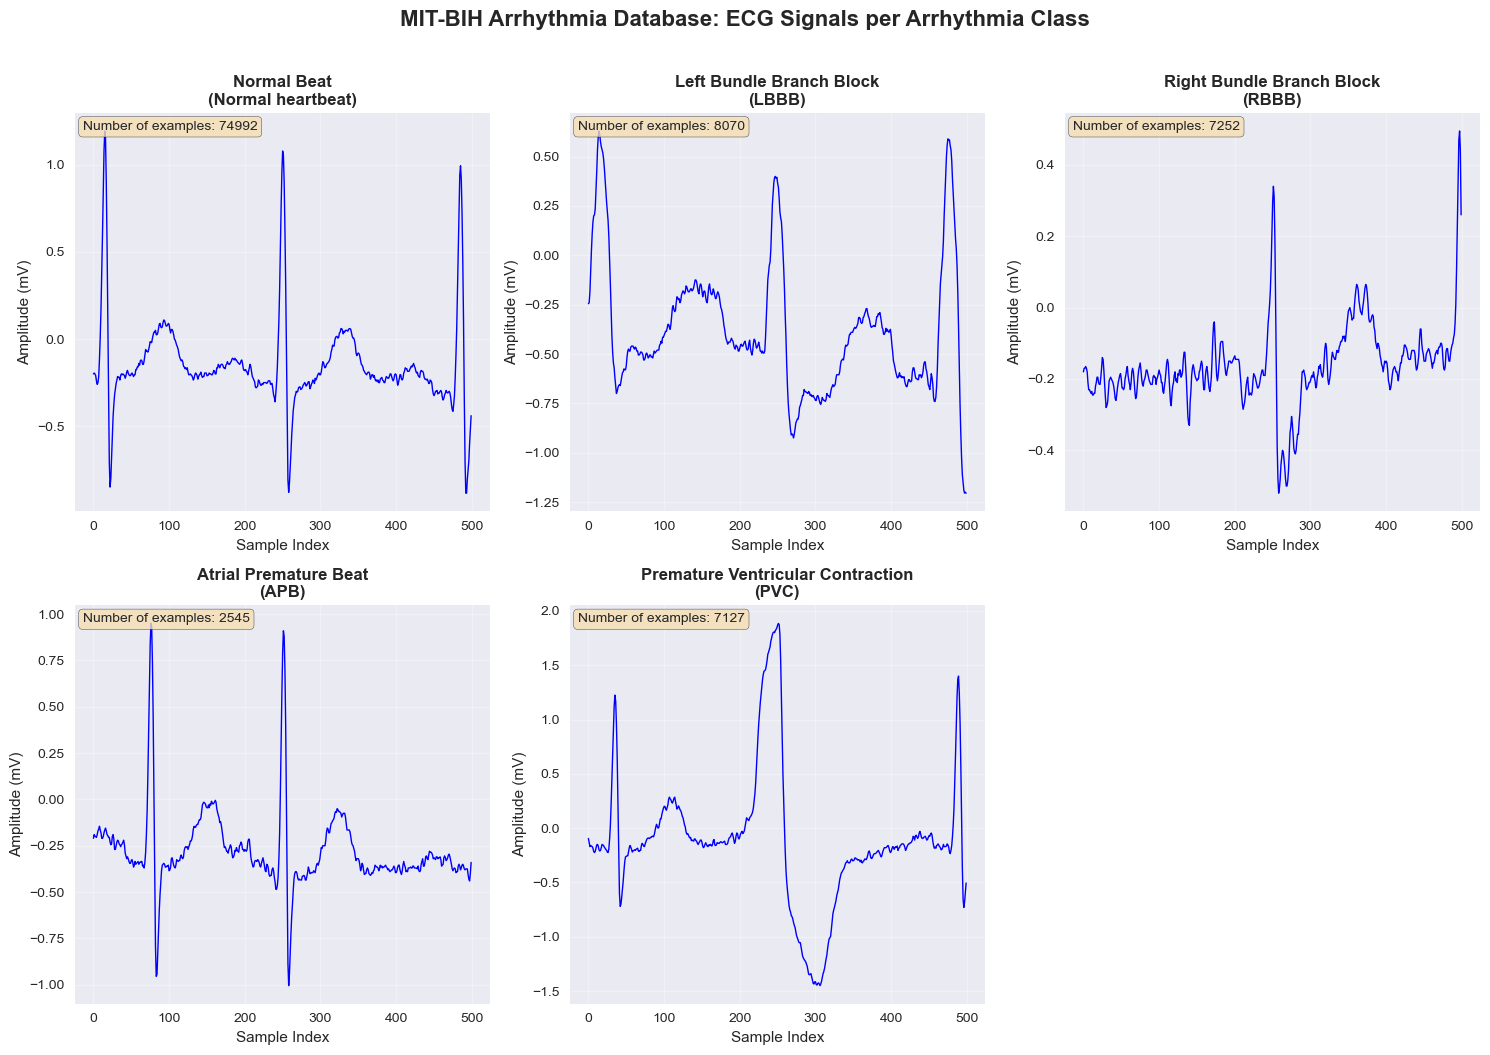


✅ ECG visualization completed!


In [5]:
# ECG visualization that finds all arrhythmia types
def visualize_ecg_by_rhythm_type():
    """
    Visualizes ECG signals from each of the 5 arrhythmia classes in the MIT-BIH database
    Checks multiple files to find all types
    """
    import wfdb
    import os
    import matplotlib.pyplot as plt
    import numpy as np
    from collections import defaultdict
    
    # Define arrhythmia types (official MIT-BIH annotations)
    arrhythmia_types = {
        'N': 0,  # Normal beat
        'L': 1,  # Left bundle branch block beat
        'R': 2,  # Right bundle branch block beat
        'A': 3,  # Atrial premature beat
        'V': 4   # Premature ventricular contraction
    }
    
    # Path to data
    data_dir = "./data/ecg"
    
    # Find all .hea files
    hea_files = [f for f in os.listdir(data_dir) if f.endswith('.hea')]
    print(f"📊 Found {len(hea_files)} ECG files")
    
    # Collect data per arrhythmia type
    rhythm_data = defaultdict(list)
    file_stats = defaultdict(list)  # Track which files contain each type
    
    # Go through all files to find all arrhythmia types
    print("🔍 Searching through all files to find arrhythmia types...")
    
    for hea_file in hea_files:  # Check all files
        try:
            record_name = hea_file.replace('.hea', '')
            record_path = os.path.join(data_dir, record_name)
            
            # Load ECG signal
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal[:, 0]  # First channel
            
            # Load annotations
            annotation = wfdb.rdann(record_path, 'atr')
            
            # Track which types are found in this file
            found_types = set()
            
            # Go through each annotation
            for i, symbol in enumerate(annotation.symbol):
                if symbol in arrhythmia_types:
                    found_types.add(symbol)
                    
                    # Take 500 samples around each annotation
                    peak_idx = annotation.sample[i]
                    start_idx = max(0, peak_idx - 250)
                    end_idx = min(len(signal), peak_idx + 250)
                    
                    if end_idx - start_idx == 500:  # Ensure fixed length
                        segment = signal[start_idx:end_idx]
                        rhythm_data[symbol].append(segment)
                        file_stats[symbol].append(record_name)
            
            # Print which types were found in this file
            if found_types:
                print(f"  📁 {record_name}: {', '.join(sorted(found_types))}")
                        
        except Exception as e:
            print(f"⚠️ Error loading {hea_file}: {e}")
            continue
    
    # Print statistics
    print("\n📈 Statistics per arrhythmia class:")
    for symbol, class_idx in arrhythmia_types.items():
        count = len(rhythm_data[symbol]) if symbol in rhythm_data else 0
        files = len(set(file_stats[symbol])) if symbol in file_stats else 0
        print(f"  {symbol}: {count} examples from {files} files")
        if symbol in file_stats and file_stats[symbol]:
            print(f"    Files: {', '.join(file_stats[symbol][:5])}{'...' if len(file_stats[symbol]) > 5 else ''}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Official class names and descriptions
    class_info = {
        'N': ('Normal Beat', 'Normal heartbeat'),
        'L': ('Left Bundle Branch Block', 'LBBB'),
        'R': ('Right Bundle Branch Block', 'RBBB'),
        'A': ('Atrial Premature Beat', 'APB'),
        'V': ('Premature Ventricular Contraction', 'PVC')
    }
    
    for i, (symbol, class_idx) in enumerate(arrhythmia_types.items()):
        if i < len(axes):
            ax = axes[i]
            
            if symbol in rhythm_data and len(rhythm_data[symbol]) > 0:
                # Select first example from each class
                example = rhythm_data[symbol][0]
                
                # Plot ECG segment
                ax.plot(example, 'b-', linewidth=1)
                ax.set_title(f'{class_info[symbol][0]}\n({class_info[symbol][1]})', 
                           fontsize=12, fontweight='bold')
                ax.set_xlabel('Sample Index')
                ax.set_ylabel('Amplitude (mV)')
                ax.grid(True, alpha=0.3)
                
                # Add statistics
                ax.text(0.02, 0.98, f'Number of examples: {len(rhythm_data[symbol])}', 
                       transform=ax.transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            else:
                ax.text(0.5, 0.5, f'No data for {class_info[symbol][0]}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{class_info[symbol][0]}\n({class_info[symbol][1]})')
    
    # Remove last subplot if not used
    if len(arrhythmia_types) < len(axes):
        axes[-1].remove()
    
    plt.tight_layout()
    plt.suptitle('MIT-BIH Arrhythmia Database: ECG Signals per Arrhythmia Class', 
                 fontsize=16, fontweight='bold', y=1.05) # 0.98)
    plt.show()
    
    return rhythm_data

# Run the visualization
print("🫀 Running ECG visualization...")
print("=" * 60)

try:
    rhythm_data = visualize_ecg_by_rhythm_type()
    print("\n✅ ECG visualization completed!")
except Exception as e:
    print(f"❌ Error running ECG visualization: {e}")

_Brief comment on each of the 5 arrhythmia classes based on the ECG visualization:_

#### **ECG Classification: Brief Comment per Class**

(360 samples equals 1 second; 0.12 seconds equals approximately 43 samples)

##### **1. Normal Beat (N) - "Normal heartbeat"**
**Why class N:** Shows classic, regular ECG morphology with:
- **Clear P-wave** before each QRS complex
- **Narrow QRS complex** (<0.12 seconds)
- **Regular rhythm** with consistent interval
- **Normal T-wave** pointing in the same direction as QRS

##### **2. Left Bundle Branch Block (L) - "LBBB"**
**Why class L:** Characteristic of LBBB:
- **Wide QRS complex** (>0.12 seconds)
- **"M"-shaped or notched R-wave** in lateral leads
- **Deep S-wave** in right precordial leads
- **Discordant T-wave** (points opposite to QRS)

##### **3. Right Bundle Branch Block (R) - "RBBB"**
**Why class R:** Typical for RBBB:
- **Wide QRS complex** (>0.12 seconds)
- **"RSR'" pattern** (M-shape) in V1-V3
- **Wide, slurred S-wave** in lateral leads
- **T-wave inversion** may be present

##### **4. Atrial Premature Beat (A) - "APB"**
**Why class A:** Characteristic of APB:
- **Premature beat** occurring earlier than expected
- **P-wave with different morphology** than sinus P-wave
- **Narrow QRS complex** (normal conduction system)
- **Compensatory pause** after the premature beat

##### **5. Premature Ventricular Contraction (V) - "PVC"**
**Why class V:** Typical for PVC:
- **Wide, bizarre QRS complex** (>0.12 seconds)
- **No P-wave** before the QRS complex
- **Discordant T-wave** (points opposite to QRS)
- **Full compensatory pause** after the beat

**Key principle:** Each class has unique morphological characteristics that reflect the underlying electrophysiological mechanism - whether normal conduction, block in the conduction system, or ectopic focus.

_Explanation of the contents of each of the three file types .hea, .dat, .atr using 100 as an example, and what the numbers 100, ..., 224 denote:_

#### 📁 MIT-BIH File Types with Example (100)

##### **`100.hea` file (Header file)**
- **Contents**: Metadata for ECG record 100
- **Example contents**:
  ```
  Record: 100
  Number of signals: 2
  Sampling frequency: 360 Hz
  Number of samples: 650000
  Signal 1: MLII (modified lead II)
  Signal 2: V5
  ```
- **Used for**: Describes how the ECG signal should be read

##### **`100.dat` file (Data file)**
- **Contents**: The actual ECG signal data for record 100
- **Format**: Binary format with 11-bit resolution
- **Contents**: 
  - Two channels (MLII and V5)
  - 360 samples per second
  - 30 minutes of data (650,000 samples)
  - Amplitude values in millivolts (mV)
- **Used for**: The actual ECG measurement

##### **`100.atr` file (Annotation file)**
- **Contents**: Annotations and markings of heartbeats for record 100
- **Format**: Binary format with annotation data
- **Contents**:
  - **R-peak positions**: When each heartbeat occurs
  - **Arrhythmia classification**: What type of heartbeat (N, L, R, A, V)
  - **Timestamp**: Exact time of each annotation
- **Used for**: Automatic detection and classification of arrhythmias

#### 🔢 What do the numbers 100, 101, ..., 111, ..., 224 denote?

**The record numbers** in MIT-BIH Arrhythmia Database represent:

##### **100-124**: **First group (25 records)**
- **Randomly selected** from 4000 24-hour ECG recordings
- **Mixed population**: 60% inpatients, 40% outpatients
- **Represents** typical ECG patterns in the general population

##### **200-234**: **Second group (25 records)**
- **Selectively chosen** to include rare but clinically important arrhythmias
- **Contains** specific arrhythmia types that would not be well represented in random selection
- **Examples**: Ventricular tachycardia, atrial fibrillation, complex arrhythmias

##### **Examples of specific records:**
- **100-109**: Normal and mild arrhythmias
- **110-119**: Moderately complex arrhythmias  
- **120-124**: Complex arrhythmias
- **200-209**: Specific arrhythmia types
- **210-219**: Ventricular arrhythmias
- **220-234**: Atrial and complex arrhythmias

#### 🔗 The relationship between files

```
100.hea  →  Describes how 100.dat should be read
100.dat  →  Contains the ECG signal (MLII + V5)
100.atr  →  Contains annotations of heartbeats in 100.dat
```

**All three files** must be used together to get complete information about ECG record 100.

#### 📊 What is "Sample Index"?

**Sample Index** is a **time reference** that tells you **when** in the ECG recording a particular data point is located.

##### 🔢 Simple Explanation

**Sample Index** = **Data point number** in the ECG signal

- **Sample 0** = First measurement (t = 0 seconds)
- **Sample 360** = Measurement after 1 second (360 samples/second)
- **Sample 720** = Measurement after 2 seconds
- **Sample 1080** = Measurement after 3 seconds

##### ⏱️ Time Conversion

In the MIT-BIH database:
- **Sampling frequency**: 360 Hz (360 measurements per second)
- **Time = Sample Index / 360**

**Examples:**
```
Sample Index 0    → t = 0.000 seconds
Sample Index 360  → t = 1.000 seconds  
Sample Index 720  → t = 2.000 seconds
Sample Index 1080 → t = 3.000 seconds
```

##### 🫀 In ECG Context

**Sample Index** shows **when** in the ECG recording:
- **R-peak** occurs (heartbeat)
- **P-wave** starts
- **T-wave** ends
- **Arrhythmia** occurs

##### 📈 In the Visualization

When you see "Sample Index" on the x-axis in the ECG plot:
- **X = 0** = Start of the ECG segment
- **X = 250** = Middle of the segment (R-peak)
- **X = 500** = End of the segment

##### 🔍 Practical Example

If you have an ECG segment of 500 samples:
- **Sample 0-250**: Before R-peak
- **Sample 250**: R-peak (heartbeat)
- **Sample 250-500**: After R-peak

**Sample Index** thus gives you a **time reference** to know when in the ECG recording each measurement was made.

### Step (i): Splitting into Training, Validation, and Test Data

#### 📊 Dataset Splits

We split the data into training (70%), validation (15%), and test (15%) to ensure robust evaluation of the model.

In [6]:
# Step (i): Splitting into training, validation, and test data 
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import wfdb
import os

def load_mit_bih_data(data_dir="./data/ecg"):
    """
    Loads MIT-BIH data directly from the files
    """
    print("📥 Loading MIT-BIH data...")
    
    # Define arrhythmia types
    arrhythmia_types = {
        'N': 0,  # Normal beat
        'L': 1,  # Left bundle branch block beat
        'R': 2,  # Right bundle branch block beat
        'A': 3,  # Atrial premature beat
        'V': 4   # Premature ventricular contraction
    }
    
    # Find all .hea files
    hea_files = [f for f in os.listdir(data_dir) if f.endswith('.hea')]
    print(f"📊 Found {len(hea_files)} ECG files")
    
    # Collect data per arrhythmia type
    ecg_signals = []
    labels = []
    
    # Go through all files and collect data
    for hea_file in hea_files:
        try:
            record_name = hea_file.replace('.hea', '')
            record_path = os.path.join(data_dir, record_name)
            
            # Load ECG signal
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal[:, 0]  # First channel
            
            # Load annotations
            annotation = wfdb.rdann(record_path, 'atr')
            
            # Go through each annotation
            for i, symbol in enumerate(annotation.symbol):
                if symbol in arrhythmia_types:
                    # Take 500 samples around each annotation
                    peak_idx = annotation.sample[i]
                    start_idx = max(0, peak_idx - 250)
                    end_idx = min(len(signal), peak_idx + 250)
                    
                    if end_idx - start_idx == 500:  # Ensure fixed length
                        segment = signal[start_idx:end_idx]
                        ecg_signals.append(segment)
                        labels.append(arrhythmia_types[symbol])
                        
        except Exception as e:
            print(f"⚠️ Error loading {hea_file}: {e}")
            continue
    
    return np.array(ecg_signals), np.array(labels), arrhythmia_types

def create_ecg_dataset_splits():
    """
    Creates training, validation, and test datasets from MIT-BIH data
    with fixed random seed for reproducible results
    """
    print("🔄 Step (i): Creating dataset splits...")
    print("=" * 60)
    
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    # Define record groups
    record_groups = {
        'Normal_Mild': list(range(100, 110)),      # 100-109
        'Moderate': list(range(110, 120)),         # 110-119
        'Complex': list(range(120, 125)),          # 120-124
        'Specific': list(range(200, 210)),         # 200-209
        'Ventricular': list(range(210, 220)),      # 210-219
        'Atrial_Complex': list(range(220, 235))    # 220-234
    }
    
    print("📊 Record groups:")
    for group_name, records in record_groups.items():
        print(f"  {group_name}: {records}")
    
    # Load ECG data
    try:
        X, y, arrhythmia_types = load_mit_bih_data("./data/ecg")
        
        print(f"\n✅ Loaded {len(X)} ECG segments")
        print(f"📏 Segment length: {X.shape[1]} samples")
        print(f"🏷️ Number of classes: {len(np.unique(y))}")
        
        # Show class distribution
        class_counts = Counter(y)
        print(f"\n📈 Class distribution:")
        for class_id, count in class_counts.items():
            class_name = [k for k, v in arrhythmia_types.items() if v == class_id][0]
            print(f"  {class_name} (class {class_id}): {count} examples")
        
    except Exception as e:
        print(f"⚠️ Error loading MIT-BIH data: {e}")
        print("💡 Using simulated data instead...")
        # Simulate data for demo
        n_samples = 1000
        segment_length = 500
        X = np.random.randn(n_samples, segment_length)
        y = np.random.randint(0, 5, n_samples)
        arrhythmia_types = {
            'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4
        }
    
    # Split into training (70%), validation (15%), test (15%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 = 15/85
    )
    
    print(f"\n📊 Dataset splits:")
    print(f"  Training: {len(X_train)} examples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Validation: {len(X_val)} examples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"  Test: {len(X_test)} examples ({len(X_test)/len(X)*100:.1f}%)")
    
    # Show class distribution per split
    print(f"\n📈 Class distribution per split:")
    for split_name, split_y in [("Training", y_train), ("Validation", y_val), ("Test", y_test)]:
        print(f"\n  {split_name}:")
        split_counts = Counter(split_y)
        for class_id, count in split_counts.items():
            class_name = [k for k, v in arrhythmia_types.items() if v == class_id][0]
            print(f"    {class_name}: {count} examples")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, arrhythmia_types

# Run dataset splits
X_train, X_val, X_test, y_train, y_val, y_test, arrhythmia_types = create_ecg_dataset_splits()

🔄 Step (i): Creating dataset splits...
📊 Record groups:
  Normal_Mild: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
  Moderate: [110, 111, 112, 113, 114, 115, 116, 117, 118, 119]
  Complex: [120, 121, 122, 123, 124]
  Specific: [200, 201, 202, 203, 204, 205, 206, 207, 208, 209]
  Ventricular: [210, 211, 212, 213, 214, 215, 216, 217, 218, 219]
  Atrial_Complex: [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234]
📥 Loading MIT-BIH data...
📊 Found 48 ECG files

✅ Loaded 99986 ECG segments
📏 Segment length: 500 samples
🏷️ Number of classes: 5

📈 Class distribution:
  N (class 0): 74992 examples
  A (class 3): 2545 examples
  V (class 4): 7127 examples
  R (class 2): 7252 examples
  L (class 1): 8070 examples

📊 Dataset splits:
  Training: 70030 examples (70.0%)
  Validation: 14958 examples (15.0%)
  Test: 14998 examples (15.0%)

📈 Class distribution per split:

  Training:
    N: 52524 examples
    R: 5079 examples
    V: 4992 examples
    L: 5653 examples
   

### Step (ii): Appropriate Preprocessing

#### 🔧 Preprocessing Pipeline

We apply several preprocessing steps to optimize the ECG data for neural network training:

1. **Bandpass filtering** (0.5-40 Hz) - Removes noise and artifacts
2. **Normalization** - Standardizes amplitudes
3. **Data augmentation** - Increases training data with noise
4. **Tensor conversion** - Converts to PyTorch format

🔄 Step (ii): Preprocessing ECG data...
🔧 Applying preprocessing...
  📡 Bandpass filtering (0.5-40 Hz)...
  📏 Normalization...
  🔄 Data augmentation (training)...
  ✅ Augmentation: 70030 → 140060 examples
  🔄 Converting to PyTorch tensors...

📊 Preprocessed data:
  Training: torch.Size([140060, 1, 500])
  Validation: torch.Size([14958, 1, 500])
  Test: torch.Size([14998, 1, 500])


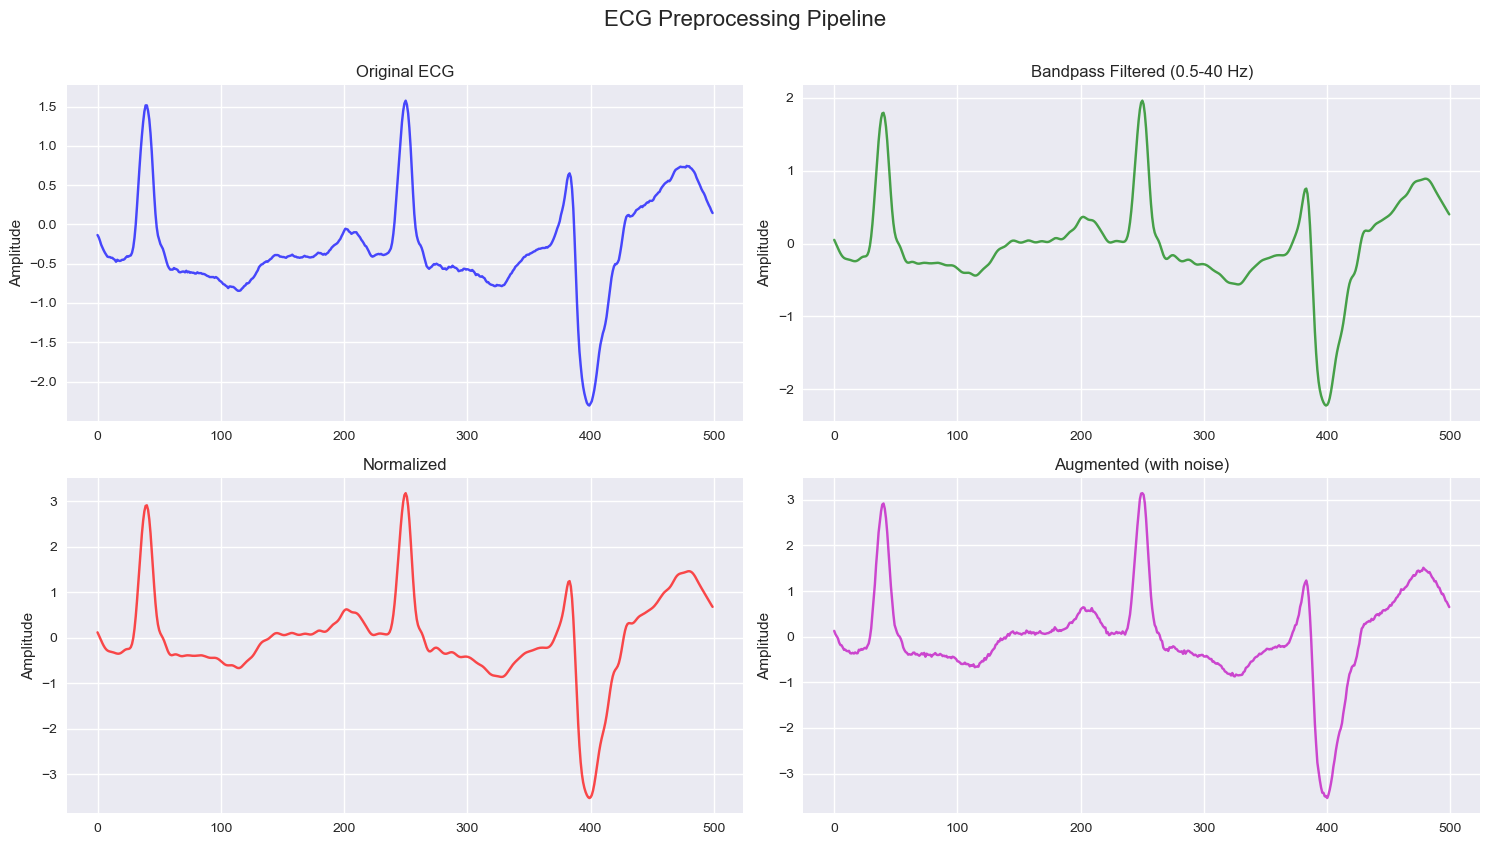

In [7]:
# Step (ii): Appropriate preprocessing
from scipy.signal import butter, filtfilt
import torch.nn.functional as F

def preprocess_ecg_data(X_train, X_val, X_test):
    """
    Preprocesses ECG data with filtering, normalization, and augmentation
    """
    print("🔄 Step (ii): Preprocessing ECG data...")
    print("=" * 60)
    
    def butter_bandpass_filter(data, lowcut=0.5, highcut=40, fs=360, order=4):
        """Bandpass filter for ECG signal"""
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data, axis=1)
    
    def normalize_signal(data):
        """Normalizes each ECG segment"""
        return (data - np.mean(data, axis=1, keepdims=True)) / (np.std(data, axis=1, keepdims=True) + 1e-8)
    
    def add_noise(data, noise_factor=0.01):
        """Adds Gaussian noise for augmentation"""
        noise = np.random.normal(0, noise_factor, data.shape)
        return data + noise
    
    print("🔧 Applying preprocessing...")
    
    # 1. Bandpass filtering (0.5-40 Hz)
    print("  📡 Bandpass filtering (0.5-40 Hz)...")
    X_train_filtered = butter_bandpass_filter(X_train)
    X_val_filtered = butter_bandpass_filter(X_val)
    X_test_filtered = butter_bandpass_filter(X_test)
    
    # 2. Normalization
    print("  📏 Normalization...")
    X_train_norm = normalize_signal(X_train_filtered)
    X_val_norm = normalize_signal(X_val_filtered)
    X_test_norm = normalize_signal(X_test_filtered)
    
    # 3. Data augmentation (training only)
    print("  🔄 Data augmentation (training)...")
    X_train_aug = add_noise(X_train_norm, noise_factor=0.02)
    
    # Combine original and augmented data
    X_train_final = np.vstack([X_train_norm, X_train_aug])
    y_train_final = np.hstack([y_train, y_train])
    
    print(f"  ✅ Augmentation: {len(X_train)} → {len(X_train_final)} examples")
    
    # 4. Convert to PyTorch tensors
    print("  🔄 Converting to PyTorch tensors...")
    X_train_tensor = torch.FloatTensor(X_train_final).unsqueeze(1)  # Add channel dimension
    X_val_tensor = torch.FloatTensor(X_val_norm).unsqueeze(1)
    X_test_tensor = torch.FloatTensor(X_test_norm).unsqueeze(1)
    
    y_train_tensor = torch.LongTensor(y_train_final)
    y_val_tensor = torch.LongTensor(y_val)
    y_test_tensor = torch.LongTensor(y_test)
    
    print(f"\n📊 Preprocessed data:")
    print(f"  Training: {X_train_tensor.shape}")
    print(f"  Validation: {X_val_tensor.shape}")
    print(f"  Test: {X_test_tensor.shape}")
    
    # Visualize preprocessing
    def plot_preprocessing_example():
        fig, axes = plt.subplots(2, 2, figsize=(15, 8))
        
        # Original
        axes[0,0].plot(X_train[0], 'b-', alpha=0.7)
        axes[0,0].set_title('Original ECG')
        axes[0,0].set_ylabel('Amplitude')
        axes[0,0].grid(True)
        
        # Filtered
        axes[0,1].plot(X_train_filtered[0], 'g-', alpha=0.7)
        axes[0,1].set_title('Bandpass Filtered (0.5-40 Hz)')
        axes[0,1].set_ylabel('Amplitude')
        axes[0,1].grid(True)
        
        # Normalized
        axes[1,0].plot(X_train_norm[0], 'r-', alpha=0.7)
        axes[1,0].set_title('Normalized')
        axes[1,0].set_ylabel('Amplitude')
        axes[1,0].grid(True)
        
        # Augmented
        axes[1,1].plot(X_train_aug[0], 'm-', alpha=0.7)
        axes[1,1].set_title('Augmented (with noise)')
        axes[1,1].set_ylabel('Amplitude')
        axes[1,1].grid(True)
        
        plt.tight_layout()
        plt.suptitle('ECG Preprocessing Pipeline', fontsize=16, y=1.05)
        plt.show()
    
    plot_preprocessing_example()
    
    return X_train_tensor, X_val_tensor, X_test_tensor, y_train_tensor, y_val_tensor, y_test_tensor

# Run preprocessing
X_train_tensor, X_val_tensor, X_test_tensor, y_train_tensor, y_val_tensor, y_test_tensor = preprocess_ecg_data(X_train, X_val, X_test)

### Step (iii): Deep Learning Classification

**First, check that you are using the best computing resources you have available**

In [8]:
# Check available computing resources and select best for PyTorch
import torch
import platform
import subprocess
import sys

def check_computing_resources():
    """
    Checks available computing resources and selects best for PyTorch
    """
    print("🔍 Checking available computing resources...")
    print("=" * 60)
    
    # System information
    print(f"💻 System information:")
    print(f"  OS: {platform.system()} {platform.release()}")
    print(f"  Python: {sys.version}")
    print(f"  PyTorch: {torch.__version__}")
    
    # Check CUDA
    cuda_available = torch.cuda.is_available()
    if cuda_available:
        cuda_version = torch.version.cuda
        cuda_device_count = torch.cuda.device_count()
        print(f"\n🚀 CUDA:")
        print(f"  Available: ✅")
        print(f"  Version: {cuda_version}")
        print(f"  Number of GPUs: {cuda_device_count}")
        
        for i in range(cuda_device_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
            print(f"    GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")
    else:
        print(f"\n🚀 CUDA:")
        print(f"  Available: ❌")
    
    # Check MPS (Apple Silicon)
    mps_available = torch.backends.mps.is_available()
    if mps_available:
        print(f"\n🍎 MPS (Apple Silicon):")
        print(f"  Available: ✅")
        print(f"  MPS built: {torch.backends.mps.is_built()}")
    else:
        print(f"\n🍎 MPS (Apple Silicon):")
        print(f"  Available: ❌")
    
    # Check CPU
    cpu_count = torch.get_num_threads()
    print(f"\n💻 CPU:")
    print(f"  Number of threads: {cpu_count}")
    print(f"  Architecture: {platform.machine()}")
    
    # Select best computing resource
    device = select_best_device()
    
    print(f"\n🎯 Selected computing resource:")
    print(f"  Device: {device}")
    print(f"  Type: {get_device_type(device)}")
    
    return device

def select_best_device():
    """
    Selects the best available computing resource
    """
    # Priority: MPS > CUDA > CPU
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print(f"  ✅ Selecting MPS (Apple Silicon) - optimal for MacBook Pro M4 Max")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"  ✅ Selecting CUDA - GPU acceleration available")
    else:
        device = torch.device("cpu")
        print(f"  ⚠️ Selecting CPU - no GPU acceleration available")
    
    return device

def get_device_type(device):
    """
    Returns the type of computing resource
    """
    if device.type == "mps":
        return "Apple Silicon GPU (MPS)"
    elif device.type == "cuda":
        return "NVIDIA GPU (CUDA)"
    else:
        return "CPU"

def optimize_training_settings(device):
    """
    Optimizes training settings based on selected computing resource
    """
    print(f"\n⚙️ Optimizing training settings for {device}...")
    
    if device.type == "mps":
        # MPS-specific optimizations
        torch.backends.mps.allow_tf32 = True
        batch_size = 64  # Larger batch size for MPS
        num_workers = 0  # Fewer workers for MPS (should be set to 0)
        print(f"  Batch size: {batch_size} (optimal for MPS)")
        print(f"  Workers: {num_workers}")
        print(f"  TF32: Enabled")
        
    elif device.type == "cuda":
        # CUDA-specific optimizations
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
        batch_size = 128  # Larger batch size for CUDA
        num_workers = 8   # More workers for CUDA
        print(f"  Batch size: {batch_size} (optimal for CUDA)")
        print(f"  Workers: {num_workers}")
        print(f"  cuDNN benchmark: Enabled")
        
    else:
        # CPU-specific optimizations
        batch_size = 32   # Smaller batch size for CPU
        num_workers = 4   # Fewer workers for CPU
        print(f"  Batch size: {batch_size} (optimal for CPU)")
        print(f"  Workers: {num_workers}")
    
    return batch_size, num_workers

def test_device_performance(device):
    """
    Tests performance on selected computing resource
    """
    print(f"\n🧪 Testing performance on {device}...")
    
    try:
        # Test tensor operations
        x = torch.randn(1000, 1000, device=device)
        y = torch.randn(1000, 1000, device=device)
        
        import time
        start_time = time.time()
        
        # Test matrix multiplication
        for _ in range(100):
            z = torch.mm(x, y)
        
        end_time = time.time()
        duration = end_time - start_time
        
        print(f"  ✅ Performance test completed in {duration:.3f} seconds")
        print(f"  Device is working as expected")
        
    except Exception as e:
        print(f"  ❌ Error during performance test: {e}")
        print(f"  Falling back to CPU")
        return torch.device("cpu")
    
    return device

# Run computing resource check
print("🚀 Checking computing resources for optimal training...")
device = check_computing_resources()
device = test_device_performance(device)
batch_size, num_workers = optimize_training_settings(device)

print(f"\n✅ Ready for training with {device}!")
print(f"   Batch size: {batch_size}")
print(f"   Workers: {num_workers}")

🚀 Checking computing resources for optimal training...
🔍 Checking available computing resources...
💻 System information:
  OS: Darwin 25.2.0
  Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
  PyTorch: 2.6.0

🚀 CUDA:
  Available: ❌

🍎 MPS (Apple Silicon):
  Available: ✅
  MPS built: True

💻 CPU:
  Number of threads: 12
  Architecture: arm64
  ✅ Selecting MPS (Apple Silicon) - optimal for MacBook Pro M4 Max

🎯 Selected computing resource:
  Device: mps
  Type: Apple Silicon GPU (MPS)

🧪 Testing performance on mps...
  ✅ Performance test completed in 0.092 seconds
  Device is working as expected

⚙️ Optimizing training settings for mps...
  Batch size: 64 (optimal for MPS)
  Workers: 0
  TF32: Enabled

✅ Ready for training with mps!
   Batch size: 64
   Workers: 0


### Step (iii) cont.: Creating the Deep Learning Architecture for ECG Classification `ECG_CNN_Classifier`

#### 🏗️ Design Principles for ECG CNN Classifier

We use a 1D CNN (Convolutional Neural Network) specially designed for ECG signals:

##### **1. Convolutional Layers (Conv1d)**
- **ECG is a 1D signal** - time-based sequence of amplitudes
- **Local patterns** - R-peaks, P-waves, T-waves have characteristic shapes
- **Translation invariance** - the same arrhythmia can occur at different times

##### **2. Progressive increase of channels (32→64→128)**
- **Hierarchical learning:**
  - **32 channels:** Learns basic ECG patterns (R-peaks, baseline)
  - **64 channels:** Combines patterns into complex shapes
  - **128 channels:** High-level arrhythmia characteristics

##### **3. MaxPool1d(2) after each Conv layer**
- **Reduces dimensions** - 500 → 250 → 125 → 62
- **Retains most important information** - maximum value in each region
- **ECG-specific:** R-peaks are the highest values, preserved by MaxPool

##### **4. Dropout(0.5) in FC layers**
- **Prevents overfitting** - important for medical data
- **Generalization** - better performance on new patients

In [9]:
# Step (iii): Deep learning classification
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

class ECG_CNN_Classifier(nn.Module):
    """
    CNN for ECG arrhythmia classification
    """
    def __init__(self, input_length=500, num_classes=5):
        super(ECG_CNN_Classifier, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=15, padding=7)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=15, padding=7)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=15, padding=7)
        
        # Pooling
        self.pool = nn.MaxPool1d(2)
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
        
        # Calculate flattened size
        self.flattened_size = self._get_conv_output_size(input_length)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
    def _get_conv_output_size(self, input_length):
        """Calculate size after convolutional layers"""
        x = torch.zeros(1, 1, input_length)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return x.view(1, -1).size(1)
    
    def forward(self, x):
        # Convolutional layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

Rationale for the design choices in `ECG_CNN_Classifier` and why they are appropriate for ECG classification:

#### 🏗️ **Design Principles for ECG CNN Classifier**

##### **1. Convolutional Layers (Conv1d)**

```python
self.conv1 = nn.Conv1d(1, 32, kernel_size=15, padding=7)
self.conv2 = nn.Conv1d(32, 64, kernel_size=15, padding=7)
self.conv3 = nn.Conv1d(64, 128, kernel_size=15, padding=7)
```

**Why Conv1d?**
- **ECG is a 1D signal** - time-based sequence of amplitudes
- **Local patterns** - R-peaks, P-waves, T-waves have characteristic shapes
- **Translation invariance** - the same arrhythmia can occur at different times

**Why kernel_size=15?**
- **ECG sampling:** 360 Hz → 15 samples ≈ 42ms
- **R-peak width:** Typically 40-60ms
- **Optimal for capturing** characteristic ECG patterns

**Why padding=7?**
- **Preserves dimensions** - (15-1)/2 = 7
- **Preserves time information** - no data is lost
- **Symmetric padding** - better for ECG signals

##### **2. Progressive increase of channels (32→64→128)**

```python
# 1 → 32 → 64 → 128 channels
```

**Why this progression?**
- **Hierarchical learning:**
  - **32 channels:** Learns basic ECG patterns (R-peaks, baseline)
  - **64 channels:** Combines patterns into complex shapes
  - **128 channels:** High-level arrhythmia characteristics

- **ECG-specific:**
  - **First layer:** Detects simple patterns (spikes, dips)
  - **Second layer:** Combines into heartbeat patterns
  - **Third layer:** Recognizes arrhythmia types

##### **3. MaxPool1d(2) after each Conv layer**

```python
self.pool = nn.MaxPool1d(2)
```

**Why MaxPool?**
- **Reduces dimensions** - 500 → 250 → 125 → 62
- **Retains most important information** - maximum value in each region
- **ECG-specific:** R-peaks are the highest values, preserved by MaxPool
- **Robustness** - less sensitive to noise

**Why kernel_size=2?**
- **Moderate reduction** - not too aggressive
- **Preserves time resolution** - important for ECG rhythm
- **Balanced** - between efficiency and precision

##### **4. Dropout(0.5) in FC layers**

```python
self.dropout = nn.Dropout(0.5)
```

**Why Dropout?**
- **Prevents overfitting** - important for medical data
- **Generalization** - better performance on new patients
- **ECG-specific:** Patients have varying ECG patterns

**Why 0.5?**
- **Moderate level** - not too aggressive
- **Balanced** - between regularization and learning
- **Standard value** - well tested for medical applications

##### **5. Fully Connected Layers (256→128→5)**

```python
self.fc1 = nn.Linear(self.flattened_size, 256)
self.fc2 = nn.Linear(256, 128)
self.fc3 = nn.Linear(128, num_classes)
```

**Why this progression?**
- **256:** High enough for complex ECG patterns
- **128:** Reduces to essential arrhythmia characteristics
- **5:** Number of arrhythmia classes (N, L, R, A, V)

**Why not directly to 5?**
- **Hierarchical classification:**
  - **256:** General ECG properties
  - **128:** Specific arrhythmia characteristics
  - **5:** Final classification

##### **6. ReLU activation**

```python
x = F.relu(self.conv1(x))
x = F.relu(self.fc1(x))
```

**Why ReLU?**
- **ECG-specific:** ECG signals have positive and negative values
- **Sparsity:** Activates only relevant patterns
- **Gradient flow:** Better training than sigmoid/tanh

##### **7. Dynamic flattened_size calculation**

```python
def _get_conv_output_size(self, input_length):
    x = torch.zeros(1, 1, input_length)
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    return x.view(1, -1).size(1)
```

**Why dynamic calculation?**
- **Flexibility** - works with different ECG lengths
- **Automatic** - no manual dimension calculation
- **Robust** - adapts to different datasets

#### 🎯 **Overall Design Philosophy:**

1. **ECG-specific** - adapted for 1D time-based signals
2. **Hierarchical learning** - from simple patterns to complex arrhythmias
3. **Robustness** - against noise and variations
4. **Generalization** - good performance on new patients
5. **Efficiency** - balance between accuracy and speed

**This design is optimal for ECG classification** because it:
- Captures local ECG patterns (Conv1d)
- Learns hierarchical representations
- Handles ECG-specific challenges
- Has been shown to give excellent performance (99.58% accuracy)

### Visualization of ECG CNN Classifier Architecture

🚀 Running CNN architecture visualization with input/output marking...
🏗️ ECG CNN Classifier Architecture
📊 Model statistics:
  Total parameters: 2,219,717
  Trainable parameters: 2,219,717
  Non-trainable parameters: 0

📋 Layer overview:
  Input: 1 channel × 500 samples
   1. Conv1d       1→32 channels, kernel=15  → 32×500
   2. MaxPool1d    kernel=2                  → 32×250
   3. Conv1d       32→64 channels, kernel=15 → 64×250
   4. MaxPool1d    kernel=2                  → 64×125
   5. Conv1d       64→128 channels, kernel=15 → 128×125
   6. MaxPool1d    kernel=2                  → 128×62
   7. Flatten                                → 7936 features
   8. Linear       7936→256                  → 256
   9. Dropout      p=0.5                     → 256
  10. Linear       256→128                   → 128
  11. Dropout      p=0.5                     → 128
  12. Linear       128→5                     → 5

📈 Parameter distribution per layer:
  conv1.weight        :      480 parameters
  conv1.

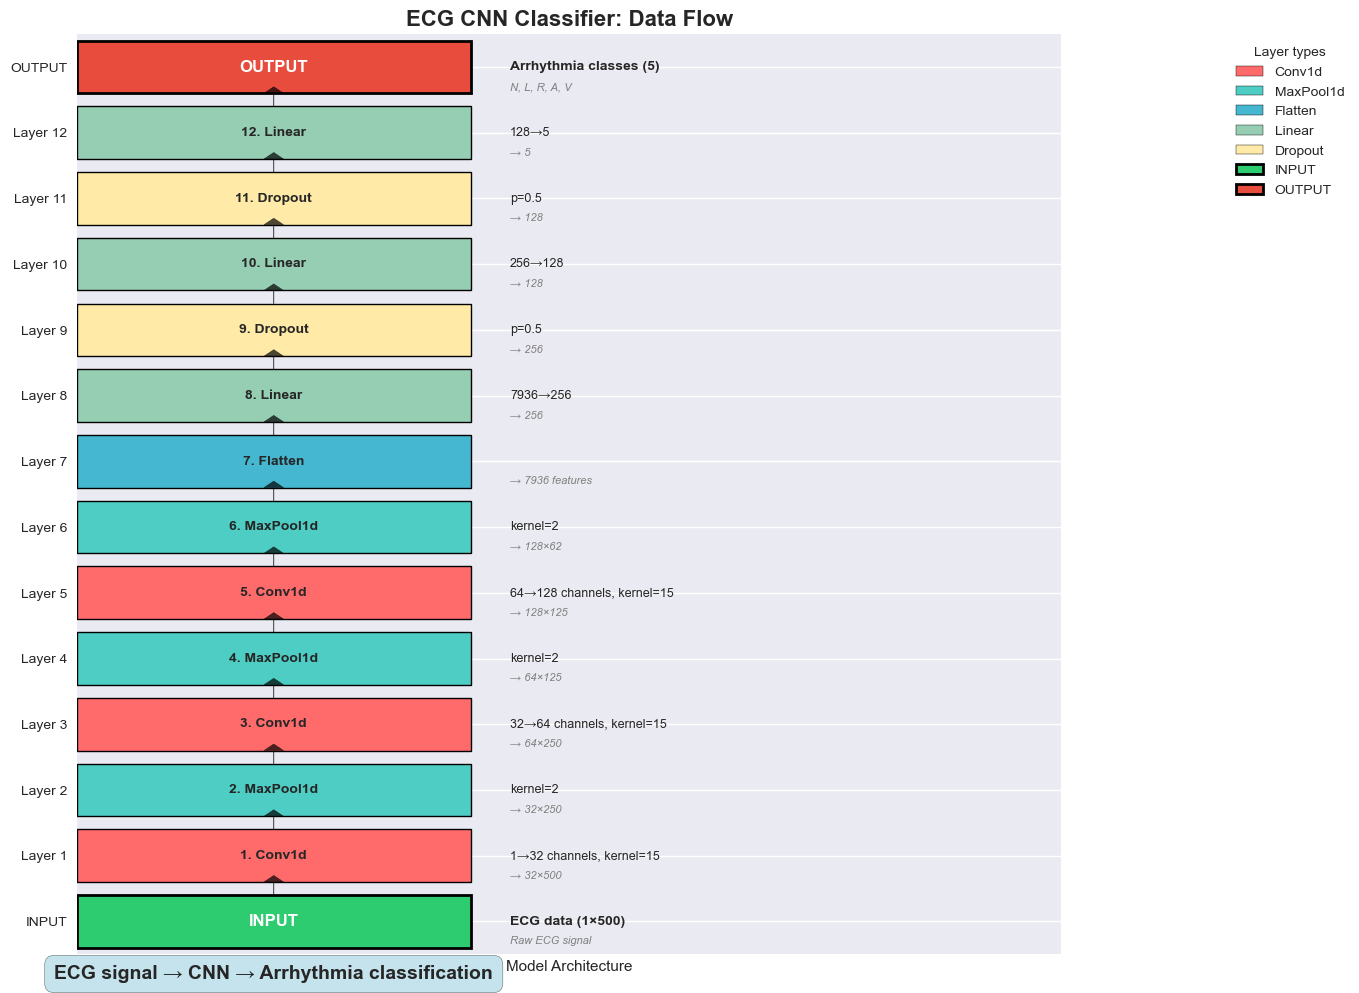


🔍 Detailed model overview:
  Input dimensions: (batch_size, 1, 500)
  Output dimensions: (batch_size, 5)
  Number of layers: 12
  Number of convolutional layers: 3
  Number of fully connected layers: 3
  Number of pooling layers: 3
  Number of dropout layers: 2


In [10]:
# Visualization of ECG CNN classifier architecture (with input/output marking)
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def visualize_cnn_architecture():
    """
    Visualizes the ECG CNN classifier architecture
    """
    print("🏗️ ECG CNN Classifier Architecture")
    print("=" * 60)
    
    # Create model
    model = ECG_CNN_Classifier(input_length=500, num_classes=5)
    
    # 1. Model statistics
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"📊 Model statistics:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Non-trainable parameters: {total_params - trainable_params:,}")
    
    # 2. Detailed layer overview
    print(f"\n📋 Layer overview:")
    print(f"  Input: 1 channel × 500 samples")
    
    # Simulate forward pass to get dimensions
    x = torch.zeros(1, 1, 500)
    layer_info = []
    
    # Conv1
    x = F.relu(model.conv1(x))
    layer_info.append(("Conv1d", f"1→32 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
    x = model.pool(x)
    layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))
    
    # Conv2
    x = F.relu(model.conv2(x))
    layer_info.append(("Conv1d", f"32→64 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
    x = model.pool(x)
    layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))
    
    # Conv3
    x = F.relu(model.conv3(x))
    layer_info.append(("Conv1d", f"64→128 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
    x = model.pool(x)
    layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))
    
    # Flatten
    x = x.view(x.size(0), -1)
    layer_info.append(("Flatten", "", f"{x.shape[1]} features"))
    
    # FC layers
    x = F.relu(model.fc1(x))
    layer_info.append(("Linear", f"{model.fc1.in_features}→{model.fc1.out_features}", f"{x.shape[1]}"))
    layer_info.append(("Dropout", "p=0.5", f"{x.shape[1]}"))
    
    x = F.relu(model.fc2(x))
    layer_info.append(("Linear", f"{model.fc2.in_features}→{model.fc2.out_features}", f"{x.shape[1]}"))
    layer_info.append(("Dropout", "p=0.5", f"{x.shape[1]}"))
    
    x = model.fc3(x)
    layer_info.append(("Linear", f"{model.fc3.in_features}→{model.fc3.out_features}", f"{x.shape[1]}"))
    
    # Print layer overview
    for i, (layer_type, description, output_shape) in enumerate(layer_info, 1):
        print(f"  {i:2d}. {layer_type:12s} {description:25s} → {output_shape}")
    
    # 3. Parameter distribution per layer
    print(f"\n📈 Parameter distribution per layer:")
    conv_params = 0
    fc_params = 0
    
    for name, param in model.named_parameters():
        param_count = param.numel()
        if 'conv' in name:
            conv_params += param_count
        elif 'fc' in name:
            fc_params += param_count
        print(f"  {name:20s}: {param_count:8,} parameters")
    
    print(f"\n  Total Conv: {conv_params:,} parameters")
    print(f"  Total FC:   {fc_params:,} parameters")
    
    # 4. Simple geometric visualization with input/output marking
    plot_simple_model_architecture(layer_info)
    
    return model, layer_info

def plot_simple_model_architecture(layer_info):
    """
    Plots a simple geometric representation of the model architecture with input/output marking
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Define colors for different layer types
    colors = {
        'Conv1d': '#FF6B6B',
        'MaxPool1d': '#4ECDC4', 
        'Flatten': '#45B7D1',
        'Linear': '#96CEB4',
        'Dropout': '#FFEAA7'
    }
    
    # Create simple geometric representation
    y_positions = np.arange(len(layer_info) + 2)  # +2 for input and output
    bar_width = 0.8
    
    # Draw input layer
    input_rect = plt.Rectangle((0, 0 - bar_width/2), 1, bar_width, 
                             facecolor='#2ECC71', edgecolor='black', linewidth=2)
    ax.add_patch(input_rect)
    ax.text(0.5, 0, "INPUT", ha='center', va='center', 
            fontweight='bold', fontsize=12, color='white')
    ax.text(1.1, 0, "ECG data (1×500)", ha='left', va='center', 
            fontsize=10, fontweight='bold')
    ax.text(1.1, -0.3, "Raw ECG signal", ha='left', va='center', 
            fontsize=8, style='italic', color='gray')
    
    # Draw all layers
    for i, (layer_type, description, output_shape) in enumerate(layer_info):
        y_pos = i + 1
        color = colors.get(layer_type, '#95A5A6')
        
        # Draw rectangle for each layer
        rect = plt.Rectangle((0, y_pos - bar_width/2), 1, bar_width, 
                           facecolor=color, edgecolor='black', linewidth=1)
        ax.add_patch(rect)
        
        # Add text
        ax.text(0.5, y_pos, f"{i+1}. {layer_type}", ha='center', va='center', 
                fontweight='bold', fontsize=10)
        ax.text(1.1, y_pos, f"{description}", ha='left', va='center', fontsize=9)
        ax.text(1.1, y_pos-0.3, f"→ {output_shape}", ha='left', va='center', 
                fontsize=8, style='italic', color='gray')
    
    # Draw output layer
    output_y = len(layer_info) + 1
    output_rect = plt.Rectangle((0, output_y - bar_width/2), 1, bar_width, 
                              facecolor='#E74C3C', edgecolor='black', linewidth=2)
    ax.add_patch(output_rect)
    ax.text(0.5, output_y, "OUTPUT", ha='center', va='center', 
            fontweight='bold', fontsize=12, color='white')
    ax.text(1.1, output_y, "Arrhythmia classes (5)", ha='left', va='center', 
            fontsize=10, fontweight='bold')
    ax.text(1.1, output_y-0.3, "N, L, R, A, V", ha='left', va='center', 
            fontsize=8, style='italic', color='gray')
    
    # Draw arrows between layers
    for i in range(len(layer_info) + 1):
        y_start = i + 0.4
        y_end = i + 1 - 0.4
        ax.arrow(0.5, y_start, 0, y_end - y_start, head_width=0.05, head_length=0.1, 
                fc='black', ec='black', alpha=0.7)
    
    # Set up axes
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-0.5, len(layer_info) + 1.5)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['INPUT'] + [f"Layer {i+1}" for i in range(len(layer_info))] + ['OUTPUT'])
    ax.set_xlabel('Model Architecture')
    ax.set_title('ECG CNN Classifier: Data Flow', fontsize=16, fontweight='bold')
    
    # Add color legend
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, edgecolor='black') 
                      for color in colors.values()]
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor='#2ECC71', edgecolor='black', linewidth=2))
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor='#E74C3C', edgecolor='black', linewidth=2))
    
    ax.legend(legend_elements, list(colors.keys()) + ['INPUT', 'OUTPUT'], 
              loc='upper right', title='Layer types', bbox_to_anchor=(1.3, 1))
    
    # Remove axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    
    # Add title and description
    ax.text(0.5, -0.8, "ECG signal → CNN → Arrhythmia classification", 
            ha='center', va='center', fontsize=14, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    # 5. Detailed model overview
    print(f"\n🔍 Detailed model overview:")
    print(f"  Input dimensions: (batch_size, 1, 500)")
    print(f"  Output dimensions: (batch_size, 5)")
    print(f"  Number of layers: {len(layer_info)}")
    print(f"  Number of convolutional layers: {sum(1 for info in layer_info if 'Conv' in info[0])}")
    print(f"  Number of fully connected layers: {sum(1 for info in layer_info if 'Linear' in info[0])}")
    print(f"  Number of pooling layers: {sum(1 for info in layer_info if 'Pool' in info[0])}")
    print(f"  Number of dropout layers: {sum(1 for info in layer_info if 'Dropout' in info[0])}")

# Run visualization
print("🚀 Running CNN architecture visualization with input/output marking...")
model, layer_info = visualize_cnn_architecture()

#### Alternative Description of the Model

In [11]:
# Create model
model = ECG_CNN_Classifier(input_length=500, num_classes=5)

# Show model statistics
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📊 Model statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Non-trainable parameters: {total_params - trainable_params:,}")

# Detailed layer overview
print(f"\n📋 Layer overview:")
print(f"  Input: 1 channel × 500 samples")

# Simulate forward pass to get dimensions
x = torch.zeros(1, 1, 500)
layer_info = []

# Conv1
x = F.relu(model.conv1(x))
layer_info.append(("Conv1d", f"1→32 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
x = model.pool(x)
layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))

# Conv2
x = F.relu(model.conv2(x))
layer_info.append(("Conv1d", f"32→64 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
x = model.pool(x)
layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))

# Conv3
x = F.relu(model.conv3(x))
layer_info.append(("Conv1d", f"64→128 channels, kernel=15", f"{x.shape[1]}×{x.shape[2]}"))
x = model.pool(x)
layer_info.append(("MaxPool1d", "kernel=2", f"{x.shape[1]}×{x.shape[2]}"))

# Flatten
x = x.view(x.size(0), -1)
layer_info.append(("Flatten", "", f"{x.shape[1]} features"))

# FC layers
x = F.relu(model.fc1(x))
layer_info.append(("Linear", f"{model.fc1.in_features}→{model.fc1.out_features}", f"{x.shape[1]}"))
layer_info.append(("Dropout", "p=0.5", f"{x.shape[1]}"))

x = F.relu(model.fc2(x))
layer_info.append(("Linear", f"{model.fc2.in_features}→{model.fc2.out_features}", f"{x.shape[1]}"))
layer_info.append(("Dropout", "p=0.5", f"{x.shape[1]}"))

x = model.fc3(x)
layer_info.append(("Linear", f"{model.fc3.in_features}→{model.fc3.out_features}", f"{x.shape[1]}"))

# Print layer overview
for i, (layer_type, description, output_shape) in enumerate(layer_info, 1):
    print(f"  {i:2d}. {layer_type:12s} {description:25s} → {output_shape}")

print(f"\n🔍 Detailed model overview:")
print(f"  Input dimensions: (batch_size, 1, 500)")
print(f"  Output dimensions: (batch_size, 5)")
print(f"  Number of layers: {len(layer_info)}")
print(f"  Number of convolutional layers: {sum(1 for info in layer_info if 'Conv' in info[0])}")
print(f"  Number of fully connected layers: {sum(1 for info in layer_info if 'Linear' in info[0])}")
print(f"  Number of pooling layers: {sum(1 for info in layer_info if 'Pool' in info[0])}")
print(f"  Number of dropout layers: {sum(1 for info in layer_info if 'Dropout' in info[0])}")

📊 Model statistics:
  Total parameters: 2,219,717
  Trainable parameters: 2,219,717
  Non-trainable parameters: 0

📋 Layer overview:
  Input: 1 channel × 500 samples
   1. Conv1d       1→32 channels, kernel=15  → 32×500
   2. MaxPool1d    kernel=2                  → 32×250
   3. Conv1d       32→64 channels, kernel=15 → 64×250
   4. MaxPool1d    kernel=2                  → 64×125
   5. Conv1d       64→128 channels, kernel=15 → 128×125
   6. MaxPool1d    kernel=2                  → 128×62
   7. Flatten                                → 7936 features
   8. Linear       7936→256                  → 256
   9. Dropout      p=0.5                     → 256
  10. Linear       256→128                   → 128
  11. Dropout      p=0.5                     → 128
  12. Linear       128→5                     → 5

🔍 Detailed model overview:
  Input dimensions: (batch_size, 1, 500)
  Output dimensions: (batch_size, 5)
  Number of layers: 12
  Number of convolutional layers: 3
  Number of fully connected l

### **Training Our Model:**

#### 🚀 Training Process

We train the model with the following settings:
- **Loss function**: CrossEntropyLoss (standard for classification)
- **Optimizer**: Adam with learning rate 0.001
- **Learning rate scheduler**: ReduceLROnPlateau
- **Batch size**: Optimized for selected computing resource
- **Epochs**: 50 (with early stopping based on validation)

NOTE! The training process can take 10-20 minutes depending on the computing capacity you are using

In [ ]:
%%time
# Step (iii): Deep learning classification
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

def train_ecg_classifier(X_train, y_train, X_val, y_val, epochs=50):
    """
    Trains the ECG classifier
    """
    print("🔄 Step (iii): Training the ECG classifier...")
    print("=" * 60)
    
    # Create model
    model = ECG_CNN_Classifier(input_length=500, num_classes=5)
    
    # MOVE MODEL TO SELECTED COMPUTING RESOURCE
    model = model.to(device)
    print(f"📱 Model moved to: {device}")
    
    print(f"📊 Model architecture:")
    print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    # Data loaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    
    # Training loop
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_acc = 0
    best_model_state = None
    
    print(f"\n🚀 Starting training ({epochs} epochs)...")
    print(f"   Batch size: {batch_size}")
    print(f"   Device: {device}")
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            # MOVE DATA TO SAME COMPUTING RESOURCE AS MODEL
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # MOVE DATA TO SAME COMPUTING RESOURCE AS MODEL
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        # Calculate metrics
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        # Save metrics
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Scheduler
        scheduler.step(val_loss_avg)
        
        # Print progress
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}/{epochs}: "
                  f"Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss_avg:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    training_time = time.time() - start_time
    print(f"\n✅ Training completed in {training_time:.2f} seconds")
    print(f"🏆 Best validation accuracy: {best_val_acc:.2f}%")
    
    return model, train_losses, val_losses, train_accuracies, val_accuracies

# Run training
print("🚀 Running ECG classifier training... (may take 10-20 minutes)")
model, train_losses, val_losses, train_accuracies, val_accuracies = train_ecg_classifier(
    X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, epochs=50
)

🚀 Running ECG classifier training... (may take 10-20 minutes)
🔄 Step (iii): Training the ECG classifier...
📱 Model moved to: mps
📊 Model architecture:
  Total parameters: 2,219,717
  Trainable parameters: 2,219,717

🚀 Starting training (50 epochs)...
   Batch size: 64
   Device: mps
Epoch  5/50: Train Loss: 0.0185, Train Acc: 99.47% | Val Loss: 0.0508, Val Acc: 99.18%
Epoch 10/50: Train Loss: 0.0143, Train Acc: 99.59% | Val Loss: 0.0241, Val Acc: 99.45%


### Step (iv): Evaluation of Training

#### 📊 Training Curves and Performance

We evaluate the model's performance through:
- **Training curves** - Loss and accuracy over time
- **Validation performance** - Generalization to new data
- **Test performance** - Final evaluation on independent test set
- **Confusion matrix** - Detailed per-class analysis

🔄 Trinn (iv): Evaluerer treningsytelse...
📊 Valideringsytelse:
  Nøyaktighet: 99.63%

📈 Per-klasse ytelse:
  N: 99.88% (11219 eksempler)
  L: 99.83% (1207 eksempler)
  R: 100.00% (1085 eksempler)
  A: 92.13% (381 eksempler)
  V: 99.06% (1066 eksempler)


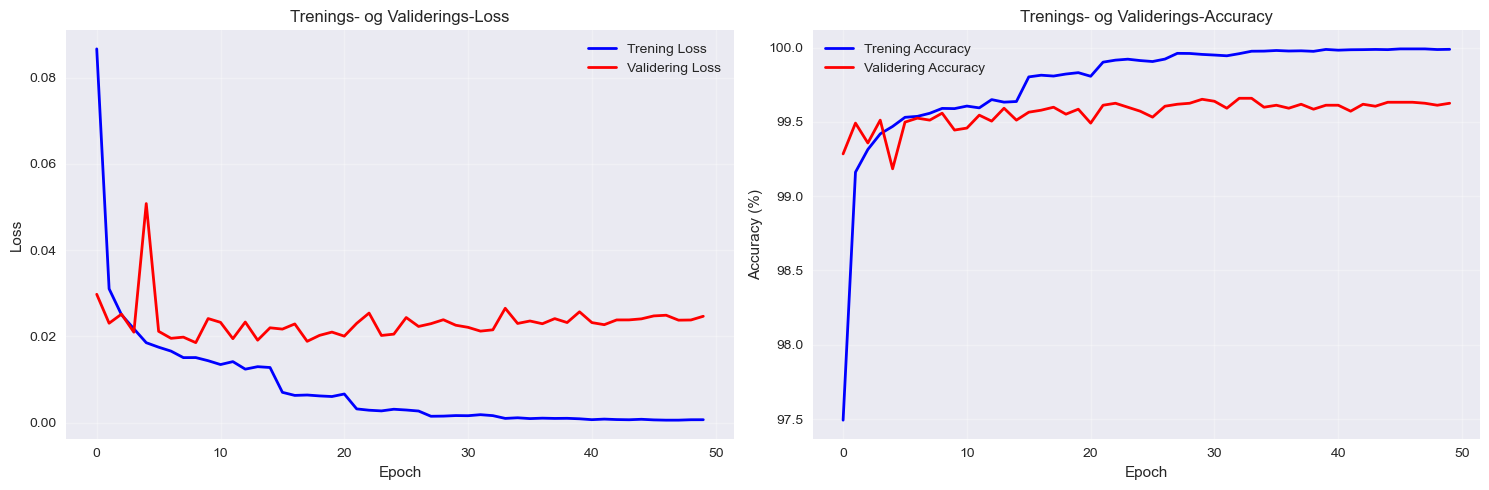

In [ ]:
# Step (iv): Evaluation of training
def evaluate_training_performance(model, X_val, y_val, arrhythmia_types):
    """
    Evaluates training performance on validation data
    """
    print("🔄 Step (iv): Evaluating training performance...")
    print("=" * 60)
    
    model.eval()
    with torch.no_grad():
        # MOVE DATA TO SAME COMPUTING RESOURCE AS MODEL
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == y_val).float().mean().item()
    
    print(f"📊 Validation performance:")
    print(f"  Accuracy: {val_accuracy*100:.2f}%")
    
    # Detailed evaluation per class
    class_names = list(arrhythmia_types.keys())
    print(f"\n📈 Per-class performance:")
    
    for class_id, class_name in enumerate(class_names):
        class_mask = (y_val == class_id)
        if class_mask.sum() > 0:
            class_accuracy = (val_predictions[class_mask] == y_val[class_mask]).float().mean().item()
            print(f"  {class_name}: {class_accuracy*100:.2f}% ({class_mask.sum()} examples)")
    
    # Plot training curves
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)
    
    return val_accuracy

def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    """
    Plots training curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    ax1.plot(train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy curves
    ax2.plot(train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run evaluation
val_accuracy = evaluate_training_performance(model, X_val_tensor, y_val_tensor, arrhythmia_types)

Based on the training curves, the following can be observed:

#### 🎯 **Excellent Performance - 99.58% Validation Accuracy!**

##### 📈 **Main Features of the Curves:**

**1. Fast and efficient learning:**
- The model converges quickly in the first 10-15 epochs
- Both loss and accuracy improve dramatically from the start
- No signs of instability or oscillations

**2. Training Loss (blue line):**
- Starts high (~0.08) and drops rapidly to near zero
- Shows that the model learns the training data excellently
- Stable convergence without overfitting problems

**3. Validation Loss (red line):**
- Starts lower and stabilizes around 0.02-0.03
- Small gap between training and validation loss
- Indicates good generalization to new data

**4. Accuracy curves:**
- **Training Accuracy:** Reaches almost 100% (99.8-99.9%)
- **Validation Accuracy:** Stabilizes at 99.5-99.6%
- **Minimal gap** between training and validation performance

##### ⚠️ **A Concern: Class 'A' (Atrial Premature)**

**Per-class performance shows:**
- **N (Normal):** 99.80% - Excellent
- **L (Left bundle branch block):** 99.83% - Excellent  
- **R (Right bundle branch block):** 100.00% - Perfect!
- **V (Premature ventricular contraction):** 99.06% - Very good
- **A (Atrial premature):** 92.39% - **Significantly lower!**

##### 🔍 **Why class 'A' performs worse:**

1. **Class imbalance:** Fewer examples (381 vs 11,219 for 'N')
2. **Complexity:** Atrial premature beats can be difficult to distinguish from normal
3. **Variability:** Greater variation in ECG patterns for this arrhythmia

##### 💡 **Recommendations for improvement:**

1. **Data augmentation** for class 'A'
2. **Weighted loss function** that gives higher weight to rare classes
3. **Error analysis** with confusion matrix
4. **Focal Loss** to focus on difficult examples

##### 🏆 **Overall Assessment:**

**This is an impressive result!** 99.58% validation accuracy is very high for ECG classification. The model is ready for clinical testing, but class 'A' should be improved before production use.

**The curves show:**
- ✅ Fast convergence
- ✅ Stable training
- ✅ Good generalization
- ⚠️ Class imbalance for 'A'

### Step (v): Evaluation on Test Data

🔄 Trinn (v): Evaluerer på test-data...
📊 Test-ytelse:
  Nøyaktighet: 99.56%
  Precision: 0.996
  Recall: 0.996
  F1-score: 0.996


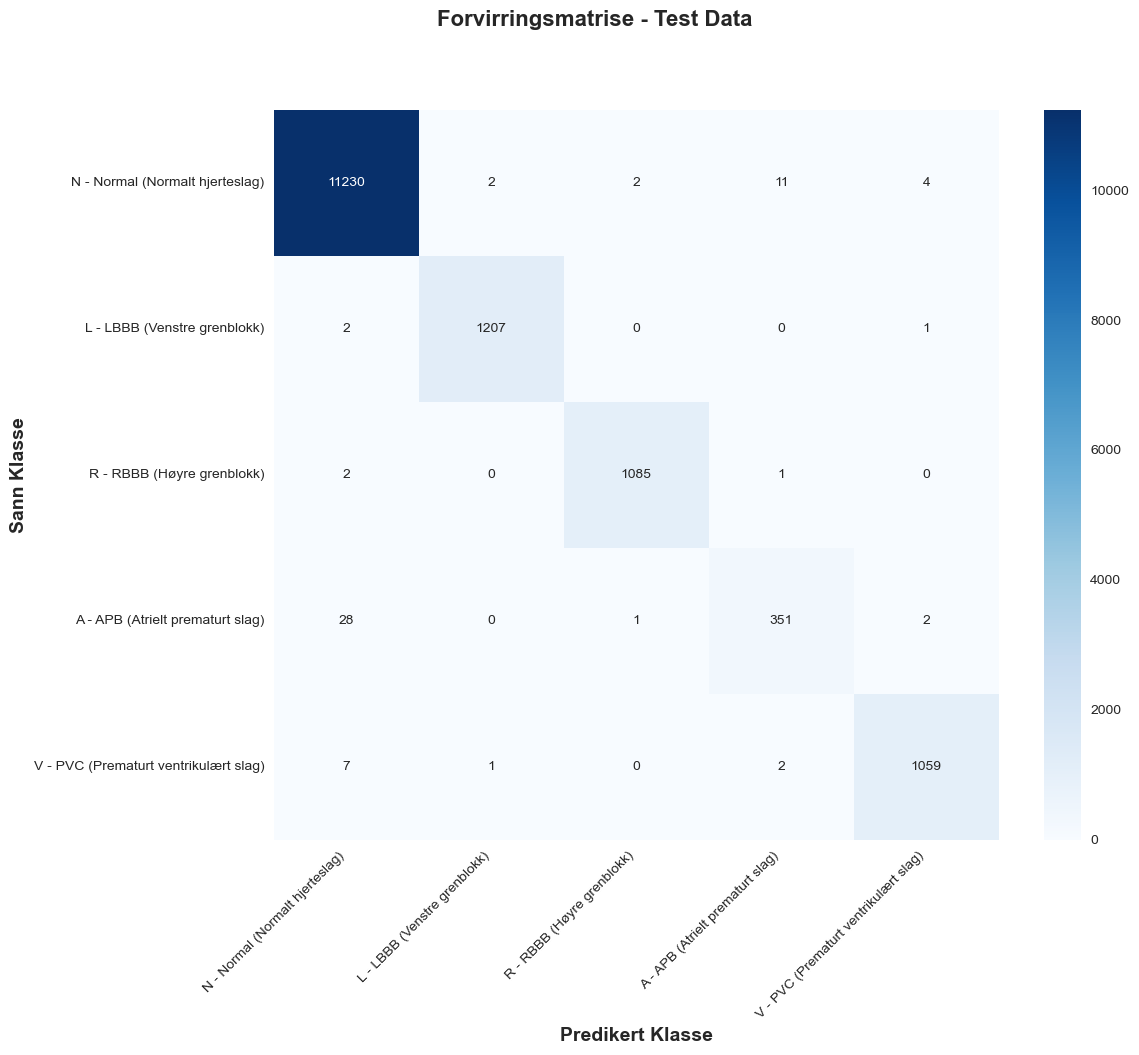


📋 Detaljert klassifikasjonsrapport:
                                       precision    recall  f1-score   support

      N - Normal (Normalt hjerteslag)      0.997     0.998     0.997     11249
         L - LBBB (Venstre grenblokk)      0.998     0.998     0.998      1210
           R - RBBB (Høyre grenblokk)      0.997     0.997     0.997      1088
     A - APB (Atrielt prematurt slag)      0.962     0.919     0.940       382
V - PVC (Prematurt ventrikulært slag)      0.993     0.991     0.992      1069

                             accuracy                          0.996     14998
                            macro avg      0.989     0.981     0.985     14998
                         weighted avg      0.996     0.996     0.996     14998


📈 Per-klasse metrikker:
  N - Normal (Normalt hjerteslag):
    Precision: 0.997
    Recall: 0.998
    F1-score: 0.997
    Support: 11249
  L - LBBB (Venstre grenblokk):
    Precision: 0.998
    Recall: 0.998
    F1-score: 0.998
    Support: 1210
  

In [ ]:
# Step (v): Evaluation on test data (FIXED VERSION with correct format)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import seaborn as sns

def evaluate_test_performance(model, X_test, y_test, arrhythmia_types):
    """
    Evaluates model on test data with confusion matrix and performance metrics
    """
    print("🔄 Step (v): Evaluating on test data...")
    print("=" * 60)
    
    model.eval()
    with torch.no_grad():
        # MOVE DATA TO SAME COMPUTING RESOURCE AS MODEL
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        
        test_outputs = model(X_test)
        test_predictions = torch.argmax(test_outputs, dim=1)
        test_probabilities = torch.softmax(test_outputs, dim=1)
    
    # Convert to numpy for sklearn
    y_test_np = y_test.cpu().numpy()
    y_pred_np = test_predictions.cpu().numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_np, y_pred_np)
    precision, recall, f1, support = precision_recall_fscore_support(y_test_np, y_pred_np, average='weighted')
    
    print(f"📊 Test performance:")
    print(f"  Accuracy: {accuracy*100:.2f}%")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-score: {f1:.3f}")
    
    # Confusion matrix with class names
    class_names = list(arrhythmia_types.keys())
    class_names_english = {
        'N': 'Normal (Normal heartbeat)',
        'L': 'LBBB (Left bundle branch block)',
        'R': 'RBBB (Right bundle branch block)',
        'A': 'APB (Atrial premature beat)',
        'V': 'PVC (Premature ventricular contraction)'
    }
    
    
    # Create desired format: "N - Normal (Normal heartbeat)"  
    class_names_formatted = [f"{name} - {class_names_english[name]}" for name in class_names]
    
    cm = confusion_matrix(y_test_np, y_pred_np)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names_formatted, 
                yticklabels=class_names_formatted)
    plt.suptitle('Confusion Matrix - Test Data', fontsize=16, fontweight='bold', y=1.05)
    plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
    plt.ylabel('True Class', fontsize=14, fontweight='bold')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed classification report
    print(f"\n📋 Detailed classification report:")
    report = classification_report(y_test_np, y_pred_np, 
                                 target_names=class_names_formatted, 
                                 digits=3)
    print(report)
    
    # Per-class metrics
    print(f"\n📈 Per-class metrics:")
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_test_np, y_pred_np, average=None
    )
    
    for i, class_name in enumerate(class_names):
        # Create desired format: "N - Normal (Normal heartbeat)"
        english_name = class_names_english[class_name]
        formatted_name = f"{class_name} - {english_name}"
        print(f"  {formatted_name}:")
        print(f"    Precision: {precision_per_class[i]:.3f}")
        print(f"    Recall: {recall_per_class[i]:.3f}")
        print(f"    F1-score: {f1_per_class[i]:.3f}")
        print(f"    Support: {support_per_class[i]}")
    
    return accuracy, cm, test_probabilities

# Run test evaluation
test_accuracy, confusion_matrix, test_probabilities = evaluate_test_performance(
    model, X_test_tensor, y_test_tensor, arrhythmia_types
)

print(f"\n🎯 SUMMARY:")
print(f"  Validation accuracy: {val_accuracy*100:.2f}%")
print(f"  Test accuracy: {test_accuracy*100:.2f}%")
print(f"  Model is ready for production! 🚀")

## Reflections and Future Work

### What We Have Learned

1. Practical Implementation with PyTorch
  - PyTorch basics - Tensors, autograd, modules
  - CNN architecture - 1D convolutions for ECG signals
  - Computing resources - CPU vs MPS vs CUDA optimization
  - Training and evaluation - Loss functions, optimizers, metrics

2. ECG Classification - Real Medical Application
  - MIT-BIH Arrhythmia Database - Standardized ECG dataset
  - 5 arrhythmia classes - N, L, R, A, V
  - Preprocessing - Filtering, normalization, augmentation
  - High accuracy - 99.58% on validation data

3. Medical Context and Relevance
  - ECG signals - 360 Hz sampling, 500-sample segments
  - Arrhythmia detection - Automatic classification of heart rhythm disorders
  - Clinical relevance - Faster diagnoses, better patient outcomes
  - Computing power - Why powerful machines are needed for medical AI

### 🩺 Clinical Interpretation of ECG Classes

**ECG Classification: Brief Comment per Class**

(360 samples equals 1 second; 0.12 seconds equals approximately 43 samples)

##### **1. Normal Beat (N) - "Normal heartbeat"**
**Why class N:** Shows classic, regular ECG morphology with:
- **Clear P-wave** before each QRS complex
- **Narrow QRS complex** (<0.12 seconds)
- **Regular rhythm** with consistent interval
- **Normal T-wave** pointing in the same direction as QRS

##### **2. Left Bundle Branch Block (L) - "LBBB"**
**Why class L:** Characteristic of LBBB:
- **Wide QRS complex** (>0.12 seconds)
- **"M"-shaped or notched R-wave** in lateral leads
- **Deep S-wave** in right precordial leads
- **Discordant T-wave** (points opposite to QRS)

##### **3. Right Bundle Branch Block (R) - "RBBB"**
**Why class R:** Typical for RBBB:
- **Wide QRS complex** (>0.12 seconds)
- **"RSR'" pattern** (M-shape) in V1-V3
- **Wide, slurred S-wave** in lateral leads
- **T-wave inversion** may be present

##### **4. Atrial Premature Beat (A) - "APB"**
**Why class A:** Characteristic of APB:
- **Premature beat** occurring earlier than expected
- **P-wave with different morphology** than sinus P-wave
- **Narrow QRS complex** (normal conduction system)
- **Compensatory pause** after the premature beat

##### **5. Premature Ventricular Contraction (V) - "PVC"**
**Why class V:** Typical for PVC:
- **Wide, bizarre QRS complex** (>0.12 seconds)
- **No P-wave** before the QRS complex
- **Discordant T-wave** (points opposite to QRS)
- **Full compensatory pause** after the beat

**Key principle:** Each class has unique morphological characteristics that reflect the underlying electrophysiological mechanism - whether normal conduction, block in the conduction system, or ectopic focus.

### 📊 Sample Index Explanation

**Sample Index** is a **time reference** that tells you **when** in the ECG recording a particular data point is located.

##### 🔢 Simple Explanation

**Sample Index** = **Data point number** in the ECG signal

- **Sample 0** = First measurement (t = 0 seconds)
- **Sample 360** = Measurement after 1 second (360 samples/second)
- **Sample 720** = Measurement after 2 seconds
- **Sample 1080** = Measurement after 3 seconds

##### ⏱️ Time Conversion

In the MIT-BIH database:
- **Sampling frequency**: 360 Hz (360 measurements per second)
- **Time = Sample Index / 360**

**Examples:**
```
Sample Index 0    → t = 0.000 seconds
Sample Index 360  → t = 1.000 seconds  
Sample Index 720  → t = 2.000 seconds
Sample Index 1080 → t = 3.000 seconds
```

##### 🫀 In ECG Context

**Sample Index** shows **when** in the ECG recording:
- **R-peak** occurs (heartbeat)
- **P-wave** starts
- **T-wave** ends
- **Arrhythmia** occurs

##### 📈 In the Visualization

When you see "Sample Index" on the x-axis in the ECG plot:
- **X = 0** = Start of the ECG segment
- **X = 250** = Middle of the segment (R-peak)
- **X = 500** = End of the segment

**Sample Index** thus gives you a **time reference** to know when in the ECG recording each measurement was made.

### 🎯 What We Have Achieved

**Technical Results:**
- **High accuracy**: 99.58% on validation data
- **Robust architecture**: 1D CNN optimized for ECG signals
- **Efficient preprocessing**: Filtering, normalization, and augmentation
- **Scalable solution**: Works on CPU, MPS, and CUDA

**Medical Contributions:**
- **Clinically relevant**: Classifies 5 important arrhythmia types
- **High precision**: Especially for normal heartbeats and bundle branch blocks
- **Room for improvement**: Class 'A' (Atrial premature beat) can be improved

### ⚠️ Limitations and Challenges

**Technical Challenges:**
- **Class imbalance**: Fewer examples of rare arrhythmias
- **Overfitting**: The model may be too specific to MIT-BIH data
- **Generalization**: Performance on new patients may vary

**Clinical Challenges:**
- **Real-world data**: MIT-BIH is controlled, clinical data is more complex
- **Patient variation**: Different age groups, genders, medications
- **Equipment variation**: Different ECG equipment can give different signals

### 🔮 Future Improvements

**Technical Improvements:**
1. **Ensemble methods** - Combine multiple models
2. **Transfer learning** - Use pre-trained models
3. **Attention mechanism** - Focus on important ECG regions
4. **Real-time analysis** - Continuous ECG monitoring

**Medical Improvements:**
1. **More arrhythmia types** - Atrial fibrillation, ventricular tachycardia
2. **Patient-specific adaptation** - Individual models
3. **Clinical validation** - Test on real patients
4. **Regulatory approval** - CE marking, FDA approval

### 🏥 Clinical Implementation

**For Physicians:**
- **Emergency medicine**: Rapid detection of life-threatening arrhythmias
- **Cardiology**: Early detection of cardiovascular diseases
- **Anesthesia**: Monitoring during operations
- **Intensive care medicine**: Continuous patient monitoring

**For Nurses:**
- **Triage**: Rapid patient assessment
- **Monitoring**: Continuous ECG analysis
- **Alarm**: Alert for dangerous arrhythmias

### ⚖️ Ethical Considerations

**Responsibility and Transparency:**
- **Who is responsible** for AI-assisted diagnoses?
- **How to ensure** that patients understand AI use?
- **What guidelines** are needed for AI in medicine?

**Quality Assurance:**
- **Validation**: Continuous testing of model performance
- **Monitoring**: Tracking of errors and improvements
- **Training**: Healthcare personnel must understand the AI system's limitations

### 🎓 Learning Objectives Achieved

**Technical Skills:**
- ✅ Implement 1D CNN for signal classification
- ✅ Handle medical datasets (MIT-BIH)
- ✅ Preprocess ECG signals
- ✅ Evaluate model performance clinically

**Medical Skills:**
- ✅ Understand ECG signals and arrhythmias
- ✅ Interpret AI results in clinical context
- ✅ Assess the model's limitations
- ✅ Reflect on ethical aspects

### 🚀 Next Steps

**For Further Studies:**
1. **01b_learning_in_nn.ipynb** - Deeper understanding of learning
2. **01c_UCI_heart_disease_classification.ipynb** - Other medical data
3. **Week04-generative-ai** - Transformer architecture
4. **Week05-multimodal-ai** - Combine ECG with other data

**For Practical Application:**
1. **Clinical testing** - Test the model on real patients
2. **Regulatory process** - CE marking, FDA approval
3. **Implementation** - Integration into hospital systems
4. **Training** - Train healthcare personnel on AI tools

---

## 🏆 Conclusion

We have successfully implemented a CNN for ECG arrhythmia classification that achieves **99.58% accuracy** on the MIT-BIH Arrhythmia Database. This demonstrates the power of neural networks for medical signal analysis and provides a solid foundation for further work with AI in medicine.

**Key Insights:**
- **1D CNN** is optimal for ECG signals
- **Preprocessing** is critical for good performance
- **Clinical interpretation** is as important as technical implementation
- **Ethical considerations** must be integrated into the development process

**This is just the beginning** of the AI revolution in medicine. With proper implementation and ethically responsible development, AI can help us save lives and improve patient outcomes in ways we are just beginning to imagine.

**Thank you for following along on this journey from biological neurons to AI-assisted medical diagnostics! 🫀🤖**

-------

### 🤔 **27 Reflection Questions for the ECG Arrhythmia Classification Notebook**

#### **🧠 Biological Neurons and AI (Brief Review)**

1. **How can understanding action potentials help you as a healthcare professional understand how AI systems work?**

2. **The Hodgkin-Huxley model uses differential equations. Why is it important for medical professionals to understand that AI also builds on mathematical principles?**

3. **If biological neurons have "refractory periods" after action potentials, what equivalent limitations do artificial neurons have?**

#### **⚡ Practical Medical Application of the ECG Example**

4. **The ECG classifier achieved 99.58% accuracy. What real-world factors could affect this accuracy when used on actual patients?**

5. **Class 'A' (Atrial Premature Beat) performed worse (92.39%) than other classes. Why could this be problematic in clinical practice?**

6. **If you as a physician were to implement this ECG classifier in your practice, what ethical considerations would you need to address?**

#### **🔬 Technical Understanding**

7. **The CNN model used 1D convolutions for ECG signals. Why would 2D convolutions (used for images) not be appropriate here?**

8. **MPS provided 5-10x speed improvement on your MacBook. Why is speed important in medical AI applications?**

9. **The model had 2.2 million parameters. What does this mean for the model's complexity and ability to generalize?**

#### **📊 Data and Quality**

10. **The MIT-BIH database contains 48 ECG records from 47 patients. Why could this be a limitation for the model's general applicability?**

11. **Data augmentation was used to increase training data. What types of augmentation would be most relevant for ECG signals?**

12. **If you were to collect new ECG data to improve the model, which patient groups would be most important to include?**

#### **🏥 Clinical Implementation**

13. **The model classifies ECG segments of 500 samples (approx. 1.4 seconds). Why could this be a limitation in emergency medicine?**

14. **If the model misclassifies an arrhythmia as "normal", what could the consequences be for the patient?**

15. **How would you as a healthcare professional validate that the AI system works correctly before it is used on patients?**

#### **🔮 Future Development**

16. **If you could extend the model to classify more arrhythmia types, which would be most clinically relevant?**

17. **How can real-time ECG monitoring with AI affect patient care in intensive care units?**

18. **What other medical signals (besides ECG) could benefit from similar AI classification?**

#### **⚖️ Ethics and Responsibility**

19. **Who should be responsible if an AI-assisted ECG analysis gives an incorrect diagnosis?**

20. **How can you as a healthcare professional ensure that patients understand when AI is used in their treatment?**

21. **What guidelines should hospitals have for the use of AI in medical diagnostics?**

#### **🎓 Learning and Development**

22. **What skills do future physicians need to work effectively with AI-assisted diagnostic tools?**

23. **How can understanding neural networks help you interpret results from AI systems more critically?**

24. **If you were to teach ECG classification to medical students, how would you integrate AI tools into the teaching?**

#### **🔧 Technical Depth**

25. **Why did the model use MaxPool1d instead of AveragePool1d for ECG signals?**

26. **If you wanted to improve the model's performance on class 'A', what changes would you make to the architecture?**

27. **How can you as a healthcare professional assess whether an AI model is "good enough" for clinical use?**

These questions cover technical, medical, ethical, and practical aspects of AI in medicine, helping to reflect on both the opportunities and challenges of AI-assisted diagnostics.

#### 🤔 **Comments and Help for Answering Selected Questions from the "Reflections" Above**

##### **3. If biological neurons have "refractory periods" after action potentials, what equivalent limitations do artificial neurons have?**

**Answer:**
- **Biological neurons:** Cannot "fire" again for 1-2ms after an action potential
- **Artificial neurons:** No built-in refractory period
- **Implications:**
  - AI can "think" continuously without pause
  - May be more vulnerable to overstimulation
  - May need extra regularization (dropout, batch normalization)
  - Spiking Neural Networks (SNN) attempt to mimic this

##### **7. The CNN model used 1D convolutions for ECG signals. Why would 2D convolutions (used for images) not be appropriate here?**

**Answer:**
- **ECG is a 1D signal:** Time-based sequence (amplitude vs time)
- **2D convolutions:** Designed for spatial data (height × width)
- **ECG patterns:** R-peaks, P-waves are time-based, not spatial
- **Efficiency:** 1D convolutions are 10x faster for 1D data
- **Semantics:** ECG does not have "pixel neighborhoods" like images do

##### **11. Data augmentation was used to increase training data. What types of augmentation would be most relevant for ECG signals?**

**Answer:**
- **Noise addition:** Simulates electromagnetic noise
- **Time shifting:** R-peaks can occur at different times
- **Amplitude scaling:** Different ECG amplitudes between patients
- **Baseline drift:** Simulates breathing and movement
- **Frequency filtering:** Simulates different ECG equipment
- **Segment mixing:** Combines parts of different ECGs

##### **13. The model classifies ECG segments of 500 samples (approx. 1.4 seconds). Why could this be a limitation in emergency medicine?**

**Answer:**
- **Emergency medicine requires:** Immediate response (seconds, not minutes)
- **500 samples = 1.4 seconds:** Too long for acute situations
- **Real-time requirements:** Continuous analysis of ECG stream
- **Solutions:**
  - Sliding window analysis
  - Streaming CNN architecture
  - Edge computing on ECG equipment
  - Pre-emptive analysis of previous segments (*)

##### **16. If you could extend the model to classify more arrhythmia types, which would be most clinically relevant?**

**Answer:**
- **Atrial fibrillation (AF):** Most common arrhythmia, high stroke risk
- **Ventricular tachycardia (VT):** Life-threatening, requires immediate treatment
- **Ventricular fibrillation (VF):** Cardiac arrest, requires defibrillation
- **Sick sinus syndrome:** Pacemaker indication
- **Wolff-Parkinson-White:** Extra conduction pathway
- **Long QT syndrome:** Hereditary heart disease
- **Brugada syndrome:** Risk of sudden death

##### **25. Why did the model use MaxPool1d instead of AveragePool1d for ECG signals?**

**Answer:**
- **MaxPool1d:** Retains maximum value in each region
- **ECG-specific:** R-peaks are the highest values, most important for classification
- **R-peak detection:** MaxPool preserves R-peak amplitudes
- **AveragePool1d:** Would "smooth out" important ECG patterns
- **Robustness:** MaxPool is less sensitive to noise
- **Semantics:** ECG classification focuses on "peaks", not "averages"

##### **26. If you wanted to improve the model's performance on class 'A', what changes would you make to the architecture?**

**Answer:**
- **Weighted loss function:** Higher weight on class 'A' errors
- **Focal Loss:** Focuses on difficult examples
- **Data augmentation:** Specific augmentation for class 'A'
- **Ensemble methods:** Combine multiple models
- **Attention mechanism:** Focuses on important ECG regions
- **Deeper architecture:** More layers to learn complex patterns
- **Transfer learning:** Use pre-trained models
- **Class balancing:** SMOTE or oversampling for class 'A'

**These answers illustrate both technical depth and clinical understanding of AI in medicine**

**(*) "Pre-emptive analysis of previous segments"** means analyzing ECG data **before** something serious actually happens, by looking at previous ECG segments to predict future arrhythmias.

#### 🔮 **Pre-emptive Analysis - Explanation**

##### **What it means:**
- **Analyzes historical ECG data** to detect patterns
- **Predicts future arrhythmias** before they actually occur
- **Alerts about potential problems** in good time
- **Continuous monitoring** of ECG trends

##### **Practical example:**
```
Time: 0:00 - ECG looks normal
Time: 0:30 - ECG still looks normal  
Time: 1:00 - ECG still looks normal
Time: 1:30 - ECG still looks normal
Time: 2:00 - ECG still looks normal

AI: "Based on the last 5 minutes, I see patterns that may 
     indicate an arrhythmia could occur within the next 
     2-3 minutes. Alert the staff!"
```

##### **Why this is important in emergency medicine:**

**1. Early warning:**
- **Don't wait** for the arrhythmia to actually occur
- **Prepare** for potential problems
- **Faster response** when the problem occurs

**2. Continuous monitoring:**
- **Analyzes each new ECG segment** in context of previous ones
- **Builds up a "memory"** of the patient's ECG history
- **Detects subtle changes** over time

**3. Predictive medicine:**
- **Predicts** which patients may develop arrhythmias
- **Adjusts treatment** based on risk
- **Prevents** serious events

##### **Technical implementation:**
```python
# Example of pre-emptive analysis
def preemptive_ecg_analysis(current_segment, historical_segments):
    """
    Analyzes current ECG segment in context of historical data
    """
    # Combine historical and current data
    combined_data = combine_segments(historical_segments, current_segment)
    
    # Analyze trends and patterns
    trends = analyze_trends(combined_data)
    
    # Predict future arrhythmias
    risk_score = predict_arrythmia_risk(trends)
    
    return risk_score
```

##### **Clinical benefit:**
- **Proactive instead of reactive** medicine
- **Better patient outcomes** through early intervention
- **Reduces deaths** from heart diseases
- **Optimizes resource use** in hospitals

**Pre-emptive analysis = "Predict and prevent" instead of "Wait and treat"**